# **ETAPA 1: `Setup` + `Carga` + `Inspeção Inicial`**

## ***Análise de Sentimento*** -- **Avaliações Amazon & Mercado Livre (pt-BR)**

**Autor:** Lucas Coutinho Boros  
**Data:** Maio/2026  
**Dataset:** [Avaliações em Português - Amazon e Mercado Livre](https://www.kaggle.com/datasets/sampaiovitor/avaliaes-em-portugus-amazon-e-mercado-livre)

---

## **Contexto de Negócio**

Em marketplaces como Amazon e Mercado Livre, avaliações de clientes são a principal fonte de feedback não estruturado sobre produtos. Compreender o sentimento por trás dessas avaliações permite:

- **Equipes de Produto:** identificar pontos de dor e features mais valorizadas
- **Marketing:** segmentar comunicação por perfil de satisfação
- **Operações:** priorizar categorias com maior volume de reclamações
- **Vendedores:** monitorar reputação e agir preventivamente

Este projeto aplica técnicas de NLP (Processamento de Linguagem Natural) em português para classificar automaticamente o sentimento de +76 mil avaliações reais, comparando o desempenho de diferentes algoritmos de classificação.

---

## **Pipeline do Projeto**

1. Carga e inspeção dos dados (Amazon + Mercado Livre)
2. Limpeza e tratamento (duplicatas, ausentes, padronização)
3. Engenharia de atributos (loja, categoria, métricas textuais)
4. Rotulação de sentimento com modelo pré-treinado (pt-BR)
5. Análise Exploratória (EDA) — distribuição de sentimentos, padrões por categoria/plataforma
6. Pré-processamento de texto (stopwords, stemming, tokenização)
7. Vetorização (Bag of Words + TF-IDF)
8. Modelagem — Naive Bayes (Gaussian, Multinomial, Bernoulli) + Logistic Regression
9. Avaliação comparativa e análise de erros
10. Serialização do melhor modelo e função de previsão

---
## 1. Setup do Ambiente

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import re
import warnings

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

# Estilo dos gráficos
plt.style.use('ggplot')
sns.set_palette('deep')

print("Bibliotecas importadas com sucesso")

Bibliotecas importadas com sucesso


---
## 2. Carga dos Dados

O dataset é composto por **dois arquivos CSV** coletados via web scraping:
- `am_scrape_final.csv` — avaliações da **Amazon Brasil**
- `ml_scrape_final.csv` — avaliações do **Mercado Livre**

As colunas têm nomes diferentes entre os arquivos, mas representam a mesma informação. Vamos padronizar e unificar em um único DataFrame.

In [2]:
# Carga dos datasets 
df_amazon = pd.read_csv('../dados/am_scrape_final.csv')
df_meli   = pd.read_csv('../dados/ml_scrape_final.csv')

print(f"Amazon:        {df_amazon.shape}")
print(f"Mercado Livre: {df_meli.shape}")
print(f"\nColunas Amazon:        {df_amazon.columns.tolist()}")
print(f"Colunas Mercado Livre: {df_meli.columns.tolist()}")

Amazon:        (9815, 4)
Mercado Livre: (59934, 4)

Colunas Amazon:        ['Search Query', 'Product Title', 'Link', 'Review']
Colunas Mercado Livre: ['Pesquisa', 'Titulo', 'Link', 'Comentario']


In [3]:
#  Inspeção rápida -> Amazon 
print("=" * 55)
print("AMAZON — am_scrape_final.csv")
print("=" * 55)
print(f"\nShape: {df_amazon.shape}")
print(f"Memória: {df_amazon.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nTipos:")
print(df_amazon.dtypes)
print(f"\nAusentes:")
print(df_amazon.isnull().sum())
print(f"\nAmostra:")
df_amazon.sample(3, random_state=42)

AMAZON — am_scrape_final.csv

Shape: (9815, 4)
Memória: 3.4 MB

Tipos:
Search Query     str
Product Title    str
Link             str
Review           str
dtype: object

Ausentes:
Search Query     0
Product Title    0
Link             0
Review           0
dtype: int64

Amostra:


,Search Query,Product Title,Link,Review
3344,social,Buena Vista Social Club - Buena Vista Social Club,https://www.amazon.com.br/dp/B095GD5WK1,"Sem palavras para esse vinil , todos merecem ter essa musicalidade em casa!Chegou muito rápido e em estado perfeito , muito bem embrulhado e empacotado para garantir que o produto chegasse sem dan..."
3852,mouse,Mouse Sem Fio 2.4GHZ USB Branco - MO286,https://www.amazon.com.br/dp/B086J6JPDF,"Usa uma pilha, mas funciona direito."
5009,aspirador,Aspirador Vertical Electrolux com Fio PowerSpeed Ultra STK15 127V,https://www.amazon.com.br/dp/B094X2N4HV,"Gostei bastt desse aspirador. Ele atende minha necessidade., além de corresponder à descrição do vendedor."


In [4]:
# Inspeção rápida -> Mercado Livre 
print("=" * 55)
print("MERCADO LIVRE — ml_scrape_final.csv")
print("=" * 55)
print(f"\nShape: {df_meli.shape}")
print(f"Memória: {df_meli.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nTipos:")
print(df_meli.dtypes)
print(f"\nAusentes:")
print(df_meli.isnull().sum())
print(f"\nAmostra:")
df_meli.sample(3, random_state=42)

MERCADO LIVRE — ml_scrape_final.csv

Shape: (59934, 4)
Memória: 21.6 MB

Tipos:
Pesquisa      str
Titulo        str
Link          str
Comentario    str
dtype: object

Ausentes:
Pesquisa      0
Titulo        0
Link          0
Comentario    0
dtype: int64

Amostra:


,Pesquisa,Titulo,Link,Comentario
11566,relogio,Relógio Digital Sport Led Homens Mulheres Adulto Infantil,https://produto.mercadolivre.com.br/MLB-1915880717-relogio-digital-sport-led-homens-mulheres-adulto-infantil-_JM#position=13&search_layout=grid&type=item&tracking_id=f304a51f-93b7-410f-bb24-bd7b0e...,Bom.
273,smartphone,"Smartphone Motorola Moto G22 Dual 6,5 128gb 4gb Ram Azul",https://produto.mercadolivre.com.br/MLB-2660980219-smartphone-motorola-moto-g22-dual-65-128gb-4gb-ram-azul-_JM#position=48&search_layout=stack&type=item&tracking_id=4703b69b-1b0f-4cc2-b281-a641f81...,"Produto bom. Pelo valor que custa, vale a pena."
45685,vestido,Vestido Madrinhas Longo Varias Formas De Uso Multiformas,https://produto.mercadolivre.com.br/MLB-1743853693-vestido-madrinhas-longo-varias-formas-de-uso-multiformas-_JM#position=1&search_layout=grid&type=item&tracking_id=c6bed7f6-ef9f-43ad-b9aa-651051b9...,"Vale o preço! vestido simples, se vc quer chamar atenção não compre! ele é tecido forro mesmo! peguei o preto então disfarçou bem ! tenho 1. 68 70 kg vestiu bem ! pouco comprido só."


In [5]:
# Padronização dos nomes de colunas e Concatenação dos Datasets
## Amazon: Search Query, Product Title, Link, Review
## Mercado Livre: Pesquisa, Titulo, Link, Comentario

df_amazon = df_amazon.rename(columns={
    'Search Query'  : 'pesquisa',
    'Product Title' : 'titulo_produto',
    'Link'          : 'link',
    'Review'        : 'review'
})
df_amazon['plataforma'] = 'Amazon'

df_meli = df_meli.rename(columns={
    'Pesquisa'   : 'pesquisa',
    'Titulo'     : 'titulo_produto',
    'Link'       : 'link',
    'Comentario' : 'review'
})
df_meli['plataforma'] = 'Mercado Livre'

# Concatenação vertical 
df = pd.concat([df_amazon, df_meli], ignore_index=True)

print(f"Shape final: {df.shape}")
print(f"Amazon:        {len(df_amazon):>6} reviews")
print(f"Mercado Livre: {len(df_meli):>6} reviews")
print(f"Total:         {len(df):>6} reviews")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nDistribuição por plataforma:")
print(df['plataforma'].value_counts())

Shape final: (69749, 5)
Amazon:          9815 reviews
Mercado Livre:  59934 reviews
Total:          69749 reviews

Colunas: ['pesquisa', 'titulo_produto', 'link', 'review', 'plataforma']

Distribuição por plataforma:
plataforma
Mercado Livre    59934
Amazon            9815
Name: count, dtype: int64


In [6]:
# Inspeção completa do dataset unificado 
print("=" * 55)
print("DATASET UNIFICADO — INSPEÇÃO COMPLETA")
print("=" * 55)

print(f"\nShape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n── Tipos de dados ──")
print(df.dtypes)

print(f"\n── Valores ausentes ──")
ausentes = df.isnull().sum()
pct = (ausentes / len(df) * 100).round(2)
resumo_ausentes = pd.DataFrame({'Ausentes': ausentes, '%': pct})
print(resumo_ausentes)

print(f"\n── Cardinalidade por coluna ──")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} valores únicos")

print(f"\n── Categorias de pesquisa ──")
print(df['pesquisa'].value_counts())

print(f"\n── Amostra aleatória ──")
df.sample(5, random_state=42)

DATASET UNIFICADO — INSPEÇÃO COMPLETA

Shape: (69749, 5)
Memória: 26.3 MB

── Tipos de dados ──
pesquisa          str
titulo_produto    str
link              str
review            str
plataforma        str
dtype: object

── Valores ausentes ──
                Ausentes    %
pesquisa               0 0.00
titulo_produto         0 0.00
link                   0 0.00
review                 0 0.00
plataforma             0 0.00

── Cardinalidade por coluna ──
  pesquisa: 43 valores únicos
  titulo_produto: 1804 valores únicos
  link: 1850 valores únicos
  review: 59952 valores únicos
  plataforma: 2 valores únicos

── Categorias de pesquisa ──
pesquisa
camiseta basica                 8161
calca jeans                     6174
joias                           4712
mochila                         4057
fones de ouvido sem fio         3868
relogio                         3432
tenis                           3305
tapete                          3061
bolsa                           2717
caixa de som p

,pesquisa,titulo_produto,link,review,plataforma
20364,caixa de som portatil,"Caixa De Som Portátil Bluetooth Jbl Go 3 4,2w À Prova D'água",https://produto.mercadolivre.com.br/MLB-1716041507-caixa-de-som-portatil-bluetooth-jbl-go-3-42w-prova-dagua-_JM#position=48&search_layout=grid&type=item&tracking_id=1aaa9b30-6a36-4ecf-84f4-25a090c...,Muito bom.,Mercado Livre
40525,tenis,Tênis Branco Lançamento Original Confortável,https://produto.mercadolivre.com.br/MLB-1611795007-tnis-branco-lancamento-original-confortavel-_JM#position=16&search_layout=grid&type=item&tracking_id=61c2d369-775f-43bd-bab7-74daa6adcd37,Veio maior do que eu pedi.,Mercado Livre
40754,tenis,Tênis Esportivo On Shoes Masculino/feminino,https://produto.mercadolivre.com.br/MLB-1464715946-tnis-esportivo-on-shoes-masculinofeminino-_JM#position=19&search_layout=grid&type=item&tracking_id=61c2d369-775f-43bd-bab7-74daa6adcd37,"Peguei o meu número correto,e ficou perfeito. Comprarei mais um.",Mercado Livre
55139,calca jeans,Calça Alfaiataria Linhão Com Botões Feminina Moda Lançamento,https://produto.mercadolivre.com.br/MLB-2621331758-calca-alfaiataria-linho-com-botoes-feminina-moda-lancamento-_JM?searchVariation=177875068661#searchVariation=177875068661&position=51&search_layo...,Muito bom adorei.,Mercado Livre
63290,joias,Atacado Kit Semi Joias 90 Peças + Mostruário Grátis,https://produto.mercadolivre.com.br/MLB-1000397072-atacado-kit-semi-joias-90-pecas-mostruario-gratis-_JM#position=8&search_layout=grid&type=item&tracking_id=08d61f6d-8e6d-4789-bf44-6c4182c63459,Boa qualidade otimo produto.,Mercado Livre


# **ETAPA 2: `Dicionário de Dados` + `Limpeza` e `Tratamento`**

---
## 3. Dicionário de Dados

| Coluna | Tipo | Descrição | Cardinalidade |
|--------|------|-----------|---------------|
| `pesquisa` | str | Termo de busca utilizado na coleta (web scraping) | 43 categorias |
| `titulo_produto` | str | Nome do produto conforme listado no marketplace | 1.804 únicos |
| `link` | str | URL do produto no marketplace de origem | 1.850 únicos |
| `review` | str | Texto da avaliação escrita pelo cliente | 59.952 únicos |
| `plataforma` | str | Marketplace de origem: Amazon ou Mercado Livre | 2 valores |

**Observações sobre a coleta:**
- Dados obtidos via web scraping pelo autor do dataset (Vitor Sampaio)
- Não há nota numérica (estrelas) — apenas o texto do review
- Não há data do review, nome do avaliador ou informações de compra
- A coluna `pesquisa` representa a query de busca, não a categoria oficial do produto

---
## 4. Limpeza e Tratamento

### 4.1 Análise de Duplicatas

O dataset possui 69.749 linhas mas apenas 59.952 reviews únicos — indicando ~14% de possíveis repetições. Antes de remover, precisamos entender se são:
- **Duplicatas exatas:** mesma review, mesmo produto, mesmo link (erro de scraping)
- **Duplicatas cruzadas:** mesma review em produtos diferentes (review genérico)
- **Duplicatas parciais:** mesmo texto com variações mínimas

In [7]:
# Análise de duplicatas 
print("=" * 55)
print("ANÁLISE DE DUPLICATAS")
print("=" * 55)

# Duplicatas exatas (todas as colunas)
dup_total = df.duplicated().sum()
print(f"\nDuplicatas exatas (todas as colunas): {dup_total} ({dup_total/len(df)*100:.2f}%)")

# Duplicatas na coluna review
dup_review = df.duplicated(subset=['review']).sum()
print(f"Reviews duplicados (texto idêntico):  {dup_review} ({dup_review/len(df)*100:.2f}%)")

# Duplicatas review + produto (mesma review no mesmo produto)
dup_rev_prod = df.duplicated(subset=['review', 'titulo_produto']).sum()
print(f"Review + Produto duplicados:          {dup_rev_prod} ({dup_rev_prod/len(df)*100:.2f}%)")

# Duplicatas review + link (mesma review no mesmo link)
dup_rev_link = df.duplicated(subset=['review', 'link']).sum()
print(f"Review + Link duplicados:             {dup_rev_link} ({dup_rev_link/len(df)*100:.2f}%)")

ANÁLISE DE DUPLICATAS

Duplicatas exatas (todas as colunas): 1657 (2.38%)
Reviews duplicados (texto idêntico):  9797 (14.05%)
Review + Produto duplicados:          1862 (2.67%)
Review + Link duplicados:             1769 (2.54%)


In [8]:
# Examinando reviews mais repetidos 
print("── Top 15 reviews mais repetidos ──\n")
top_dup = (df['review']
           .value_counts()
           .head(15)
           .reset_index()
           .rename(columns={'review': 'texto_review', 'count': 'ocorrencias'}))

for i, row in top_dup.iterrows():
    texto = row['texto_review'][:100]  # primeiros 100 caracteres
    print(f"  [{row['ocorrencias']}x] \"{texto}...\"")

# Verificar se duplicatas vêm de uma plataforma específica 
print(f"\n── Duplicatas por plataforma ──")
dup_mask = df.duplicated(subset=['review', 'titulo_produto'], keep=False)
if dup_mask.sum() > 0:
    print(df[dup_mask]['plataforma'].value_counts())

── Top 15 reviews mais repetidos ──

  [429x] "Muito bom...."
  [299x] "Bom...."
  [273x] "Excelente...."
  [262x] "Ótimo...."
  [187x] "Ótimo produto...."
  [154x] "Top...."
  [151x] "Excelente produto...."
  [147x] "Perfeito...."
  [135x] "Gostei...."
  [131x] "Amei...."
  [127x] "Otimo...."
  [113x] "Gostei muito...."
  [99x] "Maravilhoso...."
  [96x] "Recomendo...."
  [89x] "Produto muito bom...."

── Duplicatas por plataforma ──
plataforma
Amazon           3546
Mercado Livre     155
Name: count, dtype: int64


In [9]:
# Analisar um review duplicado em detalhe 
review_mais_repetido = df['review'].value_counts().index[0]
casos = df[df['review'] == review_mais_repetido]
print(f"Review mais repetido ({len(casos)}x):")
print(f"Texto: \"{review_mais_repetido[:150]}...\"\n")
print(casos[['pesquisa', 'titulo_produto', 'plataforma']].to_string())

Review mais repetido (429x):
Texto: "Muito bom...."

                           pesquisa                                                                                               titulo_produto     plataforma
3063   aparelho de barbear eletrico                                          Philips Barbeador Elétrico AquaTouch Series 1000, Bivolt - S1323/41         Amazon
4793                     fritadeira                                             Fritadeira Air Fryer Philco Gourmet 4l 1500w Preto Pfr15pg - 127         Amazon
5360          ferro de passar roupa                      Ferro de Passar a Vapor Oster Ultra Care 6204, 110V, Modelo: GCSTSP6204-017, Cor: Preto         Amazon
6256                        mochila                                        Mochila Executiva Resistente Faculdade Escola Bolsa Trabalho Notebook         Amazon
8304                        teclado                                                              Teclado Preto 0014 Bright CX 1 UN com fio e USB   

In [10]:
# Distribuição do comprimento dos reviews 
df['len_review'] = df['review'].str.len()

print("── Estatísticas do comprimento dos reviews ──")
print(f"Mínimo:   {df['len_review'].min()} caracteres")
print(f"Máximo:   {df['len_review'].max()} caracteres")
print(f"Mediana:  {df['len_review'].median():.0f} caracteres")
print(f"Média:    {df['len_review'].mean():.0f} caracteres")
print(f"Skewness: {df['len_review'].skew():.2f}")

print(f"\n── Reviews muito curtos ──")
for limite in [1, 3, 5, 10, 15]:
    n = (df['len_review'] <= limite).sum()
    print(f"  ≤ {limite:>2} chars: {n:>5} reviews ({n/len(df)*100:.2f}%)")

print(f"\n── Exemplos de reviews com ≤ 5 caracteres ──")
curtos = df[df['len_review'] <= 5]['review'].value_counts().head(10)
print(curtos)

── Estatísticas do comprimento dos reviews ──
Mínimo:   1 caracteres
Máximo:   9130 caracteres
Mediana:  51 caracteres
Média:    89 caracteres
Skewness: 16.96

── Reviews muito curtos ──
  ≤  1 chars:    12 reviews (0.02%)
  ≤  3 chars:   162 reviews (0.23%)
  ≤  5 chars:   980 reviews (1.41%)
  ≤ 10 chars:  4054 reviews (5.81%)
  ≤ 15 chars:  7157 reviews (10.26%)

── Exemplos de reviews com ≤ 5 caracteres ──
review
Bom.     299
Top.     154
Amei.    131
Boa.      52
Show.     35
Ok.       32
Bom       24
Ótimo     19
Ruim.     16
👍.        13
Name: count, dtype: int64


---
### **Diagnóstico dos Dados**
**`Duplicatas`** o que está acontecendo:


- As 1.657 duplicatas exatas (2.38%) são erros de scraping — mesma review, mesmo produto, mesmo link. Remoção segura.
- Os 9.797 reviews com texto idêntico (14.05%) são reviews legítimos de pessoas diferentes em produtos diferentes. "Muito bom" aparece 429x porque 429 pessoas escreveram exatamente isso em 429 produtos distintos. Isso não é duplicata — é a realidade de reviews de marketplace. Não vamos remover.
- O dado mais revelador: das 3.701 linhas envolvidas em duplicatas review + titulo_produto, 3.546 são da Amazon e apenas 155 do Mercado Livre. Isso confirma que o scraping da Amazon coletou reviews duplicados do mesmo produto — o Mercado Livre está muito mais limpo.


Reviews curtos -- decisão:
**Mediana** de 51 caracteres e **média** de 89 (**skewness** de 16.96) mostra que `a maioria dos reviews é curta`, com uma cauda longa de reviews detalhados. Reviews de ≤5 caracteres como "Bom.", "Top.", "Amei." carregam sentimento claro. 

O modelo pré-treinado vai conseguir classificar. Mas reviews de 1-2 caracteres (".", "👍", "k") são **ruído**. Vamos definir um limite mínimo de 3 caracteres.

---
### 4.2 Estratégia de Limpeza

**Duplicatas:**
- **Remover:** duplicatas exatas (todas as colunas iguais) → erros de scraping, especialmente da Amazon
- **Manter:** reviews com texto idêntico em produtos diferentes → comportamento legítimo de consumidores

**Reviews muito curtos (≤ 2 caracteres):**
- Reviews como ".", "👍" ou espaços não carregam informação textual suficiente para análise de sentimento
- Limite mínimo: **3 caracteres**

**Reviews ausentes ou nulos disfarçados:**
- Verificar strings vazias, espaços ou valores como "N/A" na coluna review

In [11]:
# Registrar shape inicial 
shape_inicial = df.shape[0]
print(f"Shape inicial: {df.shape}")

# 1. Remover duplicatas exatas (erro de scraping) 
df = df.drop_duplicates(keep='first')
apos_dup = df.shape[0]
print(f"\n[1] Duplicatas exatas removidas: {shape_inicial - apos_dup}")
print(f"    Shape: {df.shape}")

# 2. Verificar reviews "vazios disfarçados" 
# Strings que são só espaços, tabs, ou caracteres especiais
df['review_strip'] = df['review'].str.strip()
vazios = (df['review_strip'] == '') | (df['review_strip'].isna())
print(f"\n[2] Reviews vazios ou só espaços: {vazios.sum()}")

# 3. Remover reviews com ≤ 2 caracteres 
curtos = df['review_strip'].str.len() <= 2
print(f"[3] Reviews com ≤ 2 caracteres: {curtos.sum()}")

# Aplicando remoções 2 e 3 
remover = vazios | curtos
df = df[~remover].copy()
print(f"\n    Reviews removidos (vazios + curtos): {remover.sum()}")
print(f"    Shape após limpeza: {df.shape}")

# 4. Limpeza coluna auxiliar 
df['review'] = df['review_strip']
df = df.drop(columns=['review_strip', 'len_review'])

# Resumo final 
print(f"\n{'=' * 55}")
print(f"RESUMO DA LIMPEZA")
print(f"{'=' * 55}")
print(f"Registros iniciais:  {shape_inicial:>6}")
print(f"Registros finais:    {df.shape[0]:>6}")
print(f"Removidos:           {shape_inicial - df.shape[0]:>6} ({(shape_inicial - df.shape[0])/shape_inicial*100:.2f}%)")
print(f"Ausentes restantes:  {df.isnull().sum().sum()}")
print(f"Duplicatas exatas:   {df.duplicated().sum()}")

Shape inicial: (69749, 6)

[1] Duplicatas exatas removidas: 1657
    Shape: (68092, 6)

[2] Reviews vazios ou só espaços: 0
[3] Reviews com ≤ 2 caracteres: 59

    Reviews removidos (vazios + curtos): 59
    Shape após limpeza: (68033, 7)

RESUMO DA LIMPEZA
Registros iniciais:   69749
Registros finais:     68033
Removidos:             1716 (2.46%)
Ausentes restantes:  0
Duplicatas exatas:   0


In [12]:
# Verificação pós-limpeza 
print("── Distribuição por plataforma após limpeza ──")
print(df['plataforma'].value_counts())
print(f"\n── Proporção ──")
print((df['plataforma'].value_counts(normalize=True) * 100).round(2))

print(f"\n── Comprimento dos reviews após limpeza ──")
df['len_review'] = df['review'].str.len()
print(f"Mínimo:   {df['len_review'].min()} caracteres")
print(f"Mediana:  {df['len_review'].median():.0f} caracteres")
print(f"Média:    {df['len_review'].mean():.0f} caracteres")

print(f"\n── Top 5 reviews mais curtos restantes ──")
print(df.nsmallest(5, 'len_review')[['review', 'len_review', 'plataforma']].to_string())

print(f"\n── Categorias de pesquisa (confirmar que nenhuma foi perdida) ──")
print(f"Categorias: {df['pesquisa'].nunique()}")

── Distribuição por plataforma após limpeza ──
plataforma
Mercado Livre    59895
Amazon            8138
Name: count, dtype: int64

── Proporção ──
plataforma
Mercado Livre   88.04
Amazon          11.96
Name: proportion, dtype: float64

── Comprimento dos reviews após limpeza ──
Mínimo:   3 caracteres
Mediana:  51 caracteres
Média:    85 caracteres

── Top 5 reviews mais curtos restantes ──
    review  len_review plataforma
93     bão           3     Amazon
327    Bom           3     Amazon
453    bom           3     Amazon
594    boa           3     Amazon
707    Top           3     Amazon

── Categorias de pesquisa (confirmar que nenhuma foi perdida) ──
Categorias: 43


# **Etapa 3: `Engenharia de Atributos`**

---
## 5. Engenharia de Atributos --  Colunas Derivadas

Antes da rotulação de sentimento, vamos enriquecer o dataset com variáveis que permitem análises segmentadas:

1. **`categoria`** - macro-categoria de varejo (Eletrônicos, Moda, Casa, etc.) a partir da coluna `pesquisa`
2. **`len_review`** - comprimento do review em caracteres (já existe)
3. **`n_palavras`** - número de palavras no review

A coluna `loja` (vendedor específico) não é extraível de forma confiável o link aponta para o produto, não para o seller. A separação Amazon vs Mercado Livre já está na coluna `plataforma`.

In [13]:
# Mapeamento: pesquisa -> categoria de varejo 
# Lógica: segmentação por departamento, como um e-commerce real
# organizando esses produtos para fins de marketing e operações

mapa_categoria = {
    # Tecnologia -> eletrônicos de consumo, computação
    'smartphone'                : 'Tecnologia',
    'smart tv'                  : 'Tecnologia',
    'smart tv box'              : 'Tecnologia',
    'tablet'                    : 'Tecnologia',
    'monitor'                   : 'Tecnologia',
    'impressora'                : 'Tecnologia',
    'ssd'                       : 'Tecnologia',
    'disco'                     : 'Tecnologia',
    'camera digital'            : 'Tecnologia',
    'drone'                     : 'Tecnologia',
    
    # Acessórios Tech -> periféricos e wearables
    'fones de ouvido sem fio'   : 'Acessórios Tech',
    'caixa de som portatil'     : 'Acessórios Tech',
    'mouse'                     : 'Acessórios Tech',
    'teclado'                   : 'Acessórios Tech',
    'console de videogame'      : 'Acessórios Tech',
    'smartwatch'                : 'Acessórios Tech',
    
    # Moda -> vestuário e calçados
    'camiseta basica'           : 'Moda',
    'calca jeans'               : 'Moda',
    'vestido'                   : 'Moda',
    'tenis'                     : 'Moda',
    'sapatos sociais masculinos': 'Moda',
    'mocassim'                  : 'Moda',
    'social'                    : 'Moda',
    
    # Acessórios Pessoais -> joias, relógios, óculos, bolsas, perfumes
    'joias'                     : 'Acessórios Pessoais',
    'relogio'                   : 'Acessórios Pessoais',
    'oculos'                    : 'Acessórios Pessoais',
    'bolsa'                     : 'Acessórios Pessoais',
    'mochila'                   : 'Acessórios Pessoais',
    'perfume importado'         : 'Acessórios Pessoais',
    
    # Casa & Cozinha -> eletrodomésticos, utilidades, decoração
    'fritadeira'                : 'Casa & Cozinha',
    'air fryer'                 : 'Casa & Cozinha',
    'liquidificador'            : 'Casa & Cozinha',
    'maquina de cafe expresso'  : 'Casa & Cozinha',
    'ferro de passar roupa'     : 'Casa & Cozinha',
    'tapete'                    : 'Casa & Cozinha',
    'maquina'                   : 'Casa & Cozinha',
    
    # Climatização & Limpeza -> ventilação, purificação, aspiração
    'purificador de ar'         : 'Climatização & Limpeza',
    'ar-condicionado portatil'  : 'Climatização & Limpeza',
    'ventilador'                : 'Climatização & Limpeza',
    'aspirador'                 : 'Climatização & Limpeza',
    
    # Beleza & Cuidado Pessoal
    'chapinha de cabelo'            : 'Beleza & Cuidado Pessoal',
    'aparelho de barbear eletrico'  : 'Beleza & Cuidado Pessoal',
    
    # Escritório & Trabalho
    'cadeira de escritorio'     : 'Escritório & Trabalho',
}

# Aplicar mapeamento 
df['categoria'] = df['pesquisa'].map(mapa_categoria)

# Verificar se todas as pesquisas foram mapeadas 
nao_mapeadas = df['categoria'].isnull().sum()
print(f"Pesquisas não mapeadas: {nao_mapeadas}")
if nao_mapeadas > 0:
    print(df[df['categoria'].isnull()]['pesquisa'].value_counts())

# Distribuição das categorias 
print(f"\n── Distribuição por categoria ──")
cat_dist = df['categoria'].value_counts()
cat_pct  = (df['categoria'].value_counts(normalize=True) * 100).round(2)
resumo_cat = pd.DataFrame({'Reviews': cat_dist, '%': cat_pct})
print(resumo_cat)
print(f"\nTotal de categorias: {df['categoria'].nunique()}")

Pesquisas não mapeadas: 663
pesquisa
ssd     663
Name: count, dtype: int64

── Distribuição por categoria ──
                          Reviews     %
categoria                              
Moda                        22049 32.73
Acessórios Pessoais         16627 24.68
Acessórios Tech             10220 15.17
Casa & Cozinha               6773 10.05
Tecnologia                   5956  8.84
Climatização & Limpeza       3539  5.25
Beleza & Cuidado Pessoal     1504  2.23
Escritório & Trabalho         702  1.04

Total de categorias: 8


In [17]:
# Diagnosticando a pesquisa 'ssd' 
ssd_values = df[df['categoria'].isnull()]['pesquisa'].unique()
for val in ssd_values:
    print(f"Valor: '{val}' | Repr: {repr(val)} | Len: {len(val)}")

# Verificar no dataset original 
print(f"\nTodas as pesquisas únicas que contêm 'ssd':")
for p in df['pesquisa'].unique():
    if 'ssd' in p.lower():
        print(f"  '{p}' -> {repr(p)}")

Valor: 'ssd ' | Repr: 'ssd ' | Len: 4

Todas as pesquisas únicas que contêm 'ssd':
  'ssd ' -> 'ssd '


In [19]:
# Fix clássico de espaço trailing na pesquisa 'ssd ' 
df['pesquisa'] = df['pesquisa'].str.strip()

# Reaplicando mapeamento para os que ficaram NaN
df['categoria'] = df['pesquisa'].map(mapa_categoria)

# Verificando se todas as pesquisas foram mapeadas 
nao_mapeadas = df['categoria'].isnull().sum()
print(f"Pesquisas não mapeadas: {nao_mapeadas}")
if nao_mapeadas > 0:
    print(df[df['categoria'].isnull()]['pesquisa'].value_counts())

# Distribuição das categorias 
print(f"\n── Distribuição por categoria ──")
cat_dist = df['categoria'].value_counts()
cat_pct  = (df['categoria'].value_counts(normalize=True) * 100).round(2)
resumo_cat = pd.DataFrame({'Reviews': cat_dist, '%': cat_pct})
print(resumo_cat)
print(f"\nTotal de categorias: {df['categoria'].nunique()}")

Pesquisas não mapeadas: 0

── Distribuição por categoria ──
                          Reviews     %
categoria                              
Moda                        22049 32.41
Acessórios Pessoais         16627 24.44
Acessórios Tech             10220 15.02
Casa & Cozinha               6773  9.96
Tecnologia                   6619  9.73
Climatização & Limpeza       3539  5.20
Beleza & Cuidado Pessoal     1504  2.21
Escritório & Trabalho         702  1.03

Total de categorias: 8


In [20]:
# Features textuais 
df['n_palavras'] = df['review'].str.split().str.len()

print("── Estatísticas das métricas textuais ──\n")
print(df[['len_review', 'n_palavras']].describe().round(1))

print(f"\n── Distribuição por faixa de tamanho ──")
bins = [0, 10, 30, 100, 300, float('inf')]
labels = ['Micro (≤10)', 'Curto (11-30)', 'Médio (31-100)', 'Longo (101-300)', 'Detalhado (300+)']
df['faixa_tamanho'] = pd.cut(df['len_review'], bins=bins, labels=labels)
print(df['faixa_tamanho'].value_counts().sort_index())
print()
print((df['faixa_tamanho'].value_counts(normalize=True).sort_index() * 100).round(2))

── Estatísticas das métricas textuais ──

       len_review  n_palavras
count    68033.00    68033.00
mean        84.90       14.70
std        157.90       27.70
min          3.00        1.00
25%         30.00        5.00
50%         51.00        8.00
75%         94.00       16.00
max       9130.00     1580.00

── Distribuição por faixa de tamanho ──
faixa_tamanho
Micro (≤10)          3935
Curto (11-30)       13324
Médio (31-100)      35171
Longo (101-300)     13388
Detalhado (300+)     2215
Name: count, dtype: int64

faixa_tamanho
Micro (≤10)         5.78
Curto (11-30)      19.58
Médio (31-100)     51.70
Longo (101-300)    19.68
Detalhado (300+)    3.26
Name: proportion, dtype: float64


In [21]:
# Tabela cruzada: categoria × plataforma 
cross = pd.crosstab(
    df['categoria'], 
    df['plataforma'], 
    margins=True,
    margins_name='Total'
)
print("── Reviews por Categoria × Plataforma ──\n")
print(cross.to_string())

── Reviews por Categoria × Plataforma ──

plataforma                Amazon  Mercado Livre  Total
categoria                                             
Acessórios Pessoais         1075          15552  16627
Acessórios Tech             1795           8425  10220
Beleza & Cuidado Pessoal     405           1099   1504
Casa & Cozinha              1328           5445   6773
Climatização & Limpeza       457           3082   3539
Escritório & Trabalho        122            580    702
Moda                         867          21182  22049
Tecnologia                  2089           4530   6619
Total                       8138          59895  68033


# **Etapa 4: Rotulação de Sentimento com Modelo Pré-Treinado**

#### Agora vem a etapa mais diferenciadora do projeto! A **rotulação automática de sentimento**. 

O **`pysentimiento`** usa um **modelo BERT fine-tunado** para sentimento em português/espanhol. Ele retorna 3 classes (POS, NEG, NEU) com scores de confiança. Vamos usar isso como nosso "ground truth" para treinar os **Naive Bayes** depois.

> Aviso importante para quem for replicar o projeto: 

essa etapa é pesada computacionalmente. São 68k reviews passando por um modelo transformer. No seu computador pode levar entre 30 minutos e 2 horas dependendo de CPU/GPU. Para melhor acompanhamento do processo foi incluído uma barra de progresso e processamento em batches para visualizar o andamento. Se ficar inviável, a gente tem o plano B (léxico com LeIA, muito mais rápido).

---
## 6. Rotulação de Sentimento

Como o dataset não possui nota (estrelas) nem rótulo de sentimento, utilizamos o modelo pré-treinado **pysentimiento** (BERT fine-tunado para análise de sentimento em português) para gerar os rótulos automaticamente.

O modelo classifica cada review em 3 categorias:
- **Positivo (POS)** -- satisfação, elogio, recomendação
- **Negativo (NEG)** -- reclamação, frustração, insatisfação
- **Neutro (NEU)** -- informativo, sem carga emocional clara

Além do rótulo, o modelo retorna um **score de confiança** (0 a 1) que usaremos para:
- Filtrar classificações de baixa confiança
- Analisar a "fronteira" entre sentimentos
- Enriquecer a análise exploratória

In [2]:
# Rotulação de sentimento com modelo pré-treinado 
from pysentimiento import create_analyzer
from tqdm import tqdm
import time

# Inicializar o modelo (primeira execução baixa os pesos ~500MB)
print("Carregando modelo de sentimento (pode levar alguns minutos na primeira vez)...")
inicio_modelo = time.time()
analyzer = create_analyzer(task="sentiment", lang="pt")
print(f"Modelo carregado em {time.time() - inicio_modelo:.1f}s")

# Teste rápido com exemplos conhecidos 
testes = [
    "Produto excelente, superou minhas expectativas!",
    "Péssimo, veio quebrado e o vendedor não respondeu.",
    "Chegou no prazo.",
    "Muito bom",
    "Ruim"
]
print("\n── Teste do modelo ──")
for t in testes:
    resultado = analyzer.predict(t)
    print(f"  \"{t}\"")
    print(f"    -> {resultado.output} (confiança: {resultado.probas[resultado.output]:.3f})")
    print()

Carregando modelo de sentimento (pode levar alguns minutos na primeira vez)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2170.86it/s]


Modelo carregado em 4.0s

── Teste do modelo ──
  "Produto excelente, superou minhas expectativas!"
    -> POS (confiança: 0.978)

  "Péssimo, veio quebrado e o vendedor não respondeu."
    -> NEG (confiança: 0.990)

  "Chegou no prazo."
    -> NEU (confiança: 0.935)

  "Muito bom"
    -> POS (confiança: 0.993)

  "Ruim"
    -> NEG (confiança: 0.988)



In [23]:
# Testes avançados — casos ambíguos e realistas 
testes_avancados = [
    # Mistos (positivo + negativo na mesma frase)
    "O produto é bom mas a entrega demorou demais",
    "Gostei do celular, porém a bateria não dura nada",
    "Bonito, mas veio com defeito",
    
    # Neutros / informativos
    "Chegou no prazo, conforme anunciado",
    "É o que se espera pelo preço",
    "Produto igual ao da foto",
    
    # Gírias e linguagem informal brasileira
    "Mto top, recomendo dms",
    "uma bosta, n comprem",
    "Show de bola, nota 10",
    "Mais ou menos, nada demais",
    
    # Ironia / sarcasmo (desafio para qualquer modelo)
    "Parabéns ao vendedor que mandou o produto errado",
    "Muito bom, quebrou em 2 dias",
    
    # Reviews curtíssimos (como os do nosso dataset)
    "Bom.",
    "Péssimo",
    "Ok",
    "Amei",
    "Horrível",
    "Recomendo",
    "Não recomendo",
    
    # Emojis (comum em reviews reais)
    "Adorei ❤️",
    "👎👎👎",
]

print("── Testes avançados do modelo de sentimento ──\n")
for t in testes_avancados:
    resultado = analyzer.predict(t)
    conf = resultado.probas[resultado.output]
    # Indicador visual
    icone = {'POS': '🟢', 'NEG': '🔴', 'NEU': '🟡'}[resultado.output]
    print(f"  {icone} [{resultado.output} | {conf:.3f}] \"{t}\"")

── Testes avançados do modelo de sentimento ──

  🔴 [NEG | 0.458] "O produto é bom mas a entrega demorou demais"
  🔴 [NEG | 0.734] "Gostei do celular, porém a bateria não dura nada"
  🔴 [NEG | 0.585] "Bonito, mas veio com defeito"
  🟡 [NEU | 0.960] "Chegou no prazo, conforme anunciado"
  🟡 [NEU | 0.964] "É o que se espera pelo preço"
  🟡 [NEU | 0.930] "Produto igual ao da foto"
  🟢 [POS | 0.992] "Mto top, recomendo dms"
  🔴 [NEG | 0.992] "uma bosta, n comprem"
  🟢 [POS | 0.990] "Show de bola, nota 10"
  🟡 [NEU | 0.798] "Mais ou menos, nada demais"
  🔴 [NEG | 0.924] "Parabéns ao vendedor que mandou o produto errado"
  🔴 [NEG | 0.520] "Muito bom, quebrou em 2 dias"
  🟡 [NEU | 0.771] "Bom."
  🔴 [NEG | 0.990] "Péssimo"
  🟡 [NEU | 0.649] "Ok"
  🟢 [POS | 0.993] "Amei"
  🔴 [NEG | 0.990] "Horrível"
  🟢 [POS | 0.981] "Recomendo"
  🔴 [NEG | 0.982] "Não recomendo"
  🟢 [POS | 0.992] "Adorei ❤️"
  🟡 [NEU | 0.680] "👎👎👎"


### **Diagnóstico do Modelo**

`Acertos impressionantes:`

Gírias brasileiras perfeitas: "Mto top, recomendo dms" -> POS 0.992, "uma bosta, n comprem" -> NEG 0.992
Ironia detectada: "Parabéns ao vendedor que mandou o produto errado" -> NEG 0.924 - isso é difícil até pra humano
Negação correta: "Recomendo" -> POS vs "Não recomendo" -> NEG - o modelo entende negação
Reviews curtos claros funcionam: "Amei" POS 0.993, "Péssimo" NEG 0.990, "Horrível" NEG 0.990

`Casos interessantes para discutir:`

"Bom." classificado como NEU (0.771) — discutível, mas faz sentido: "Bom." em review de marketplace é quase um "ok, nada demais". No nosso dataset "Bom." aparece 299x, então essa classificação tem impacto grande. Aceitável.
"👎👎👎" como NEU (0.680) — aqui o modelo falhou. Emojis negativos não são o forte dele. Confiança baixa confirma a incerteza. Impacto pequeno no dataset.
"Muito bom, quebrou em 2 dias" -> NEG 0.520 - acertou o sentimento mas com confiança baixíssima. Mostra que reviews mistos com ironia implícita são a fronteira do modelo.
"O produto é bom mas a entrega demorou demais" -> NEG 0.458 - confiança abaixo de 0.5. O modelo ficou dividido, o que é honesto.

**Veredito**: o modelo é sólido para o nosso caso. Acerta os casos claros com alta confiança, tem dificuldade previsível nos ambíguos (confiança baixa sinaliza isso), e entende português informal. Seguimos com ele.

In [24]:
# Aplicação do modelo em todo o dataset 
# Processamento em batches para acompanhar progresso e evitar crash de memória

BATCH_SIZE = 64
reviews = df['review'].tolist()
sentimentos = []
scores = []

print(f"Classificando {len(reviews)} reviews em batches de {BATCH_SIZE}...")
print(f"Estimativa: ~{len(reviews)//BATCH_SIZE} batches\n")

inicio = time.time()

for i in tqdm(range(0, len(reviews), BATCH_SIZE), desc="Classificando"):
    batch = reviews[i:i+BATCH_SIZE]
    
    # Truncar reviews muito longos (limite do modelo: 512 tokens)
    batch = [r[:512] if len(r) > 512 else r for r in batch]
    
    resultados = analyzer.predict(batch)
    
    for r in resultados:
        sentimentos.append(r.output)
        scores.append(r.probas[r.output])

tempo_total = time.time() - inicio
print(f"\n✓ Classificação concluída em {tempo_total/60:.1f} minutos")
print(f"  Velocidade: {len(reviews)/tempo_total:.0f} reviews/segundo")

# Adicionar ao DataFrame 
df['sentimento'] = sentimentos
df['confianca']  = scores

# Padronizar rótulos para português 
mapa_sentimento = {'POS': 'Positivo', 'NEG': 'Negativo', 'NEU': 'Neutro'}
df['sentimento'] = df['sentimento'].map(mapa_sentimento)

print(f"\n── Distribuição de sentimentos ──")
print(df['sentimento'].value_counts())
print()
print((df['sentimento'].value_counts(normalize=True) * 100).round(2))

Classificando 68033 reviews em batches de 64...
Estimativa: ~1063 batches



Classificando: 100%|██████████| 1064/1064 [4:45:11<00:00, 16.08s/it]



✓ Classificação concluída em 285.2 minutos
  Velocidade: 4 reviews/segundo

── Distribuição de sentimentos ──
sentimento
Positivo    47946
Neutro      10594
Negativo     9493
Name: count, dtype: int64

sentimento
Positivo   70.47
Neutro     15.57
Negativo   13.95
Name: proportion, dtype: float64


In [25]:
# ── CHECKPOINT — salvar estado atual do DataFrame ────────────
df.to_csv('../dados/df_checkpoint_sentimento.csv', index=False, encoding='utf-8-sig', sep=';')
print(f"✓ Checkpoint salvo em dados/df_checkpoint_sentimento.csv")
print(f"  Shape: {df.shape}")
print(f"  Colunas: {df.columns.tolist()}")

✓ Checkpoint salvo em dados/df_checkpoint_sentimento.csv
  Shape: (68033, 11)
  Colunas: ['pesquisa', 'titulo_produto', 'link', 'review', 'plataforma', 'len_review', 'categoria', 'n_palavras', 'faixa_tamanho', 'sentimento', 'confianca']


In [4]:
# ── CARREGAR CHECKPOINT (usar quando retomar o projeto) ──────
df = pd.read_csv('../dados/df_checkpoint_sentimento.csv', encoding='utf-8-sig', sep=';')
print(f"✓ Checkpoint carregado: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nSentimentos:")
print(df['sentimento'].value_counts())

✓ Checkpoint carregado: (68033, 11)
Colunas: ['pesquisa', 'titulo_produto', 'link', 'review', 'plataforma', 'len_review', 'categoria', 'n_palavras', 'faixa_tamanho', 'sentimento', 'confianca']

Sentimentos:
sentimento
Positivo    47946
Neutro      10594
Negativo     9493
Name: count, dtype: int64


── Confiança do modelo por classe ──

              count  mean  std  min  25%  50%  75%  max
sentimento                                             
Negativo    9493.00  0.86 0.16 0.34 0.77 0.94 0.99 0.99
Neutro     10594.00  0.74 0.14 0.34 0.63 0.76 0.85 0.98
Positivo   47946.00  0.95 0.10 0.34 0.96 0.99 0.99 0.99


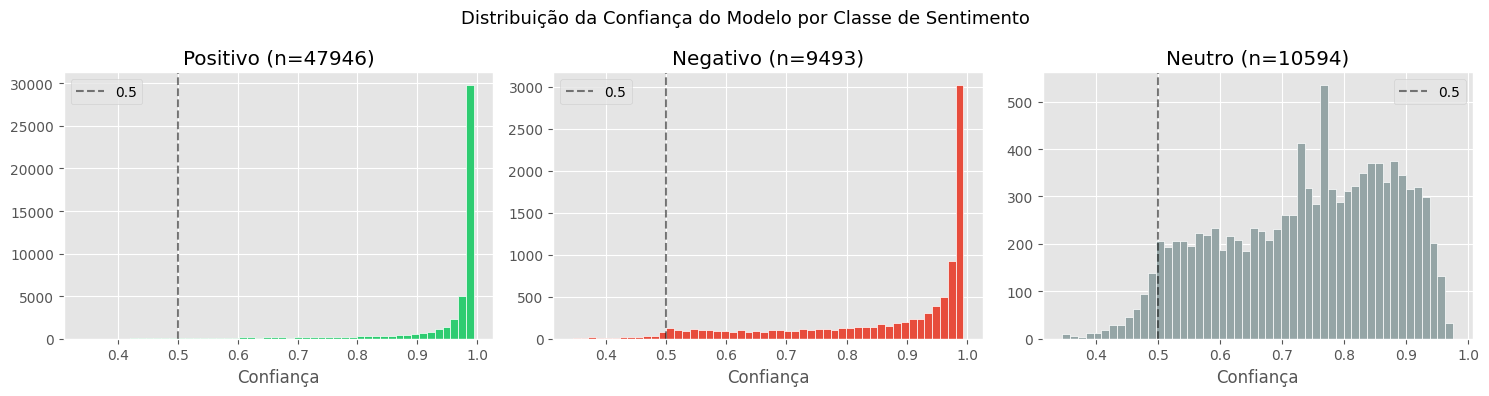


── Reviews com confiança < 0.5: 1130 (1.66%) ──
Distribuição:
sentimento
Neutro      517
Positivo    335
Negativo    278
Name: count, dtype: int64

── Exemplos de reviews com baixa confiança ──
  [Negativo | 0.495] "Forma muito larga deveria não ter a abertura do lado deveria ter a opção!!!."
  [Positivo | 0.431] "A calça e bonita porém pedi uma g porque uso 40/42 na cintura sérviu mas na perna ficou enorme uma p"
  [Neutro | 0.496] "Boa camiseta, bom tecido."
  [Neutro | 0.421] "as carteiras são bonitas, mas são de plástico muito frágil. Acho justo pelo preço"
  [Negativo | 0.460] "Não chega nem perto de ser bonito igual a foto, e maquina ourives tive de troca no msm dia que insta"


In [26]:
#  Estatísticas de confiança por sentimento 
print("── Confiança do modelo por classe ──\n")
print(df.groupby('sentimento')['confianca'].describe().round(3))

# Distribuição visual da confiança 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, sent in enumerate(['Positivo', 'Negativo', 'Neutro']):
    subset = df[df['sentimento'] == sent]['confianca']
    subset.hist(ax=axes[i], bins=50, color=['#2ecc71', '#e74c3c', '#95a5a6'][i], edgecolor='white')
    axes[i].set_title(f'{sent} (n={len(subset)})')
    axes[i].set_xlabel('Confiança')
    axes[i].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='0.5')
    axes[i].legend()
plt.suptitle('Distribuição da Confiança do Modelo por Classe de Sentimento', fontsize=13)
plt.tight_layout()
plt.show()

# Reviews com baixa confiança (zona de incerteza) 
baixa_conf = df[df['confianca'] < 0.5]
print(f"\n── Reviews com confiança < 0.5: {len(baixa_conf)} ({len(baixa_conf)/len(df)*100:.2f}%) ──")
print(f"Distribuição:")
print(baixa_conf['sentimento'].value_counts())

print(f"\n── Exemplos de reviews com baixa confiança ──")
for _, row in baixa_conf.sample(5, random_state=42).iterrows():
    print(f"  [{row['sentimento']} | {row['confianca']:.3f}] \"{row['review'][:100]}\"")

## 6.1 Diagnóstico da Rotulação -- Validação e Decisões

### Distribuição obtida
| Sentimento | Reviews | Proporção |
|------------|---------|-----------|
| Positivo | 47.946 | 70,5% |
| Neutro | 10.594 | 15,6% |
| Negativo | 9.493 | 13,9% |

A proporção **70/16/14** é consistente com o padrão esperado em marketplaces — a maioria dos consumidores que escreve reviews é satisfeita (viés de autoescolha positiva). Distribuições fora dessa faixa (ex: 95% positivo) indicariam viés do modelo, o que não ocorreu.

### Confiança do modelo por classe
- **Positivo:** mediana 0.99 — altíssima confiança. O modelo tem pouquíssima dúvida ao classificar satisfação.
- **Negativo:** mediana 0.94 — confiança alta. Reclamações têm linguagem marcada (palavras como "péssimo", "quebrou", "defeito") que o modelo reconhece com clareza.
- **Neutro:** mediana 0.76 — confiança mais baixa, esperado. Neutro é a classe mais ambígua — é a fronteira natural entre positivo e negativo.

### Testes de validação realizados
O modelo foi testado com 24 exemplos cobrindo cenários críticos:
- **Gírias brasileiras:** acertos com alta confiança ("Mto top, recomendo dms" → POS 0.992; "uma bosta, n comprem" → NEG 0.992)
- **Ironia/sarcasmo:** detectou corretamente ("Parabéns ao vendedor que mandou o produto errado" → NEG 0.924)
- **Negação:** distinguiu "Recomendo" (POS) de "Não recomendo" (NEG) — compreensão semântica real
- **Reviews curtíssimos:** classificação correta para "Amei" (POS 0.993), "Péssimo" (NEG 0.990), "Horrível" (NEG 0.990)
- **Limitações identificadas:** emojis puros ("👎👎👎" → NEU 0.680) e reviews contraditórios ("Muito bom, quebrou em 2 dias" → NEG 0.520) apresentam confiança baixa

### Reviews com baixa confiança (< 0.5)
Apenas **1.130 reviews (1,66%)** ficaram abaixo do limiar de 0.5 de confiança. Exemplos revelam que são genuinamente ambíguos:
- "A calça e bonita porém pedi uma G porque uso 40/42 na cintura sérviu mas na perna ficou enorme"
- "As carteiras são bonitas, mas são de plástico muito frágil. Acho justo pelo preço"

### Decisão: manter todos os 68.033 reviews
- O volume de classificações de baixa confiança é negligível (1,66%)
    > A remoção deles é uma questão de contexto, podendo variar com regrar de negócio, objetivo da análise e outros fatores.
- Removê-los introduziria viés de seleção — perderíamos justamente os reviews mais interessantes (os ambíguos)
- A coluna `confianca` permanece disponível como filtro opcional para análises que exijam maior certeza
- Essa abordagem preserva a integridade do dataset e permite transparência sobre a qualidade da rotulação

---
# **ETAPA 5: Análise Exploratória (EDA) - Sentimentos**

## 7. Análise Exploratória - Sentimentos

Com os 68.033 reviews rotulados, analisamos a distribuição de sentimentos por múltiplos ângulos:
- Visão geral e proporção entre classes
- Sentimento por plataforma (Amazon vs Mercado Livre)
- Sentimento por categoria de produto
- Relação entre tamanho do review e sentimento
- Palavras mais frequentes por sentimento

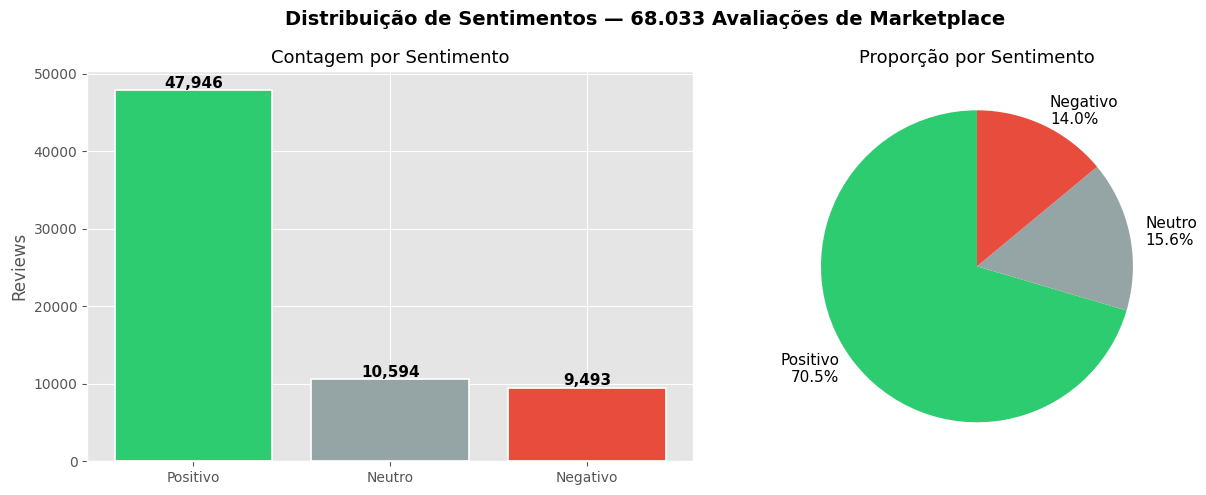

In [5]:
# Distribuição geral dos sentimentos 
cores_sentimento = {'Positivo': '#2ecc71', 'Negativo': '#e74c3c', 'Neutro': '#95a5a6'}
ordem = ['Positivo', 'Neutro', 'Negativo']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
contagem = df['sentimento'].value_counts().reindex(ordem)
bars = axes[0].bar(contagem.index, contagem.values, 
                   color=[cores_sentimento[s] for s in contagem.index],
                   edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, contagem.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem por Sentimento', fontsize=13)
axes[0].set_ylabel('Reviews')

# Pizza
proporcao = (contagem / contagem.sum() * 100).round(1)
axes[1].pie(proporcao.values, labels=[f'{s}\n{p}%' for s, p in zip(proporcao.index, proporcao.values)],
            colors=[cores_sentimento[s] for s in proporcao.index],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporção por Sentimento', fontsize=13)

plt.suptitle('Distribuição de Sentimentos — 68.033 Avaliações de Marketplace', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/distribuicao_sentimentos.png', dpi=150, bbox_inches='tight')
plt.show()

── Proporção de sentimentos por plataforma (%) ──

sentimento     Positivo  Neutro  Negativo
plataforma                               
Amazon            67.97   22.76      9.28
Mercado Livre     70.82   14.60     14.59


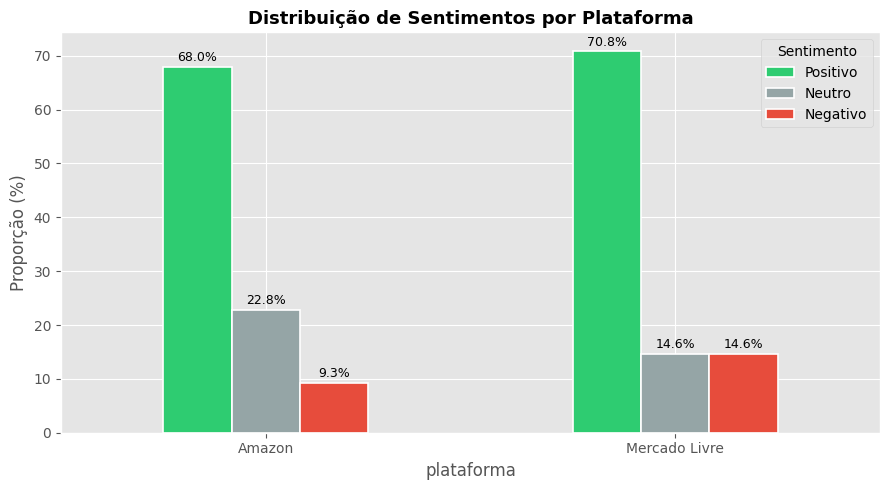

In [30]:
# Sentimento por plataforma 
cross_plat = pd.crosstab(df['plataforma'], df['sentimento'], normalize='index')
cross_plat = cross_plat.reindex(columns=ordem) * 100

print("── Proporção de sentimentos por plataforma (%) ──\n")
print(cross_plat.round(2))

# Gráfico
ax = cross_plat.plot(kind='bar', color=[cores_sentimento[s] for s in ordem],
                     figsize=(9, 5), edgecolor='white', linewidth=1.2, rot=0)
ax.set_title('Distribuição de Sentimentos por Plataforma', fontsize=13, fontweight='bold')
ax.set_ylabel('Proporção (%)')
ax.legend(title='Sentimento')

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('../outputs/sentimento_por_plataforma.png', dpi=150, bbox_inches='tight')
plt.show()

── Proporção de sentimentos por categoria (%) ──

sentimento                Positivo  Neutro  Negativo
categoria                                           
Tecnologia                   74.21   17.01      8.78
Casa & Cozinha               76.67   12.56     10.76
Beleza & Cuidado Pessoal     69.35   17.42     13.23
Moda                         69.49   16.66     13.85
Acessórios Pessoais          71.52   13.45     15.02
Acessórios Tech              67.98   15.75     16.26
Climatização & Limpeza       62.81   20.09     17.10
Escritório & Trabalho        58.83   17.52     23.65


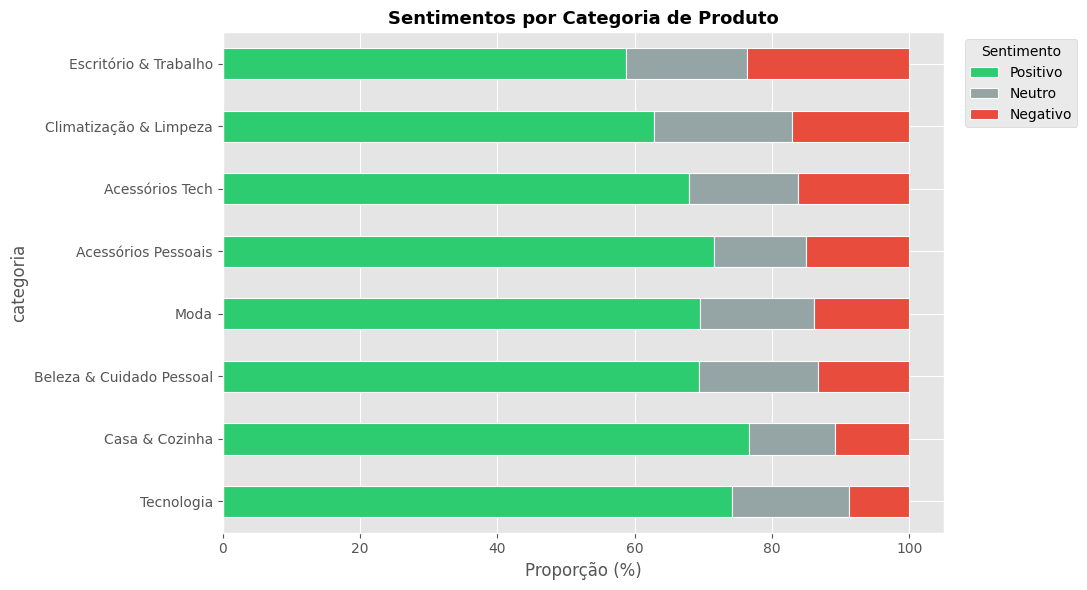

In [31]:
# Sentimento por categoria de produto 
cross_cat = pd.crosstab(df['categoria'], df['sentimento'], normalize='index')
cross_cat = cross_cat.reindex(columns=ordem) * 100

# Ordenar pela taxa de negatividade (mais negativo no topo)
cross_cat = cross_cat.sort_values('Negativo', ascending=True)

print("── Proporção de sentimentos por categoria (%) ──\n")
print(cross_cat.round(2))

# Gráfico horizontal empilhado
ax = cross_cat.plot(kind='barh', stacked=True,
                    color=[cores_sentimento[s] for s in ordem],
                    figsize=(11, 6), edgecolor='white', linewidth=0.8)
ax.set_title('Sentimentos por Categoria de Produto', fontsize=13, fontweight='bold')
ax.set_xlabel('Proporção (%)')
ax.legend(title='Sentimento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/sentimento_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

── Estatísticas de comprimento por sentimento ──

             mean   50%    75%     max
sentimento                            
Negativo   113.90 81.00 142.00 4511.00
Neutro     120.40 55.00 107.00 9130.00
Positivo    71.30 46.00  82.00 5024.00

            mean   50%   75%     max
sentimento                          
Negativo   20.40 15.00 26.00  783.00
Neutro     21.50 10.00 19.00 1580.00
Positivo   12.00  7.00 14.00  896.00


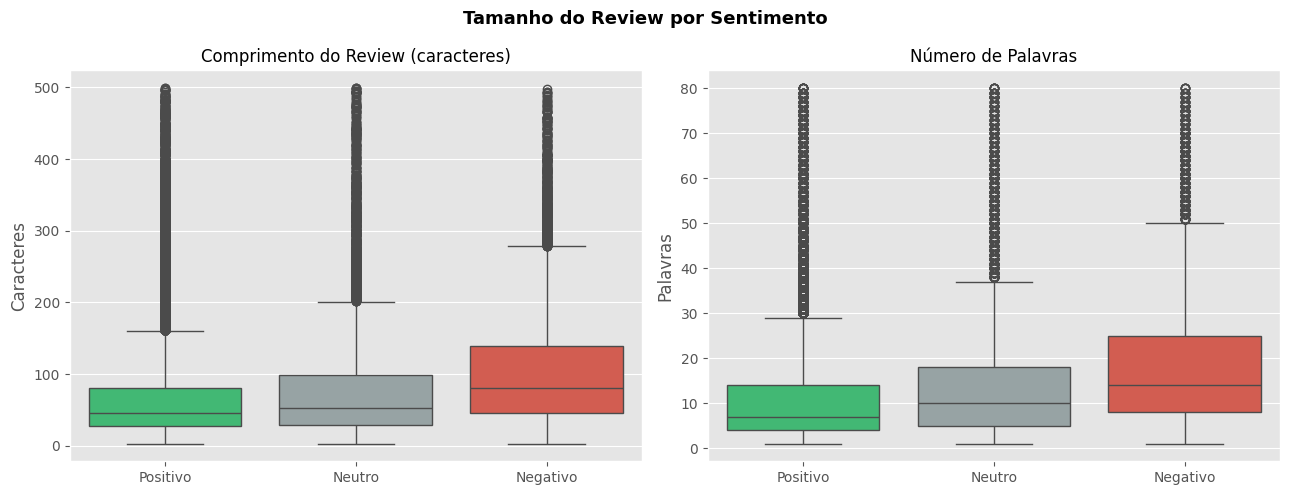

In [32]:
# Relação entre tamanho do review e sentimento 
print("── Estatísticas de comprimento por sentimento ──\n")
print(df.groupby('sentimento')['len_review'].describe()[['mean', '50%', '75%', 'max']].round(1))
print()
print(df.groupby('sentimento')['n_palavras'].describe()[['mean', '50%', '75%', 'max']].round(1))

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Comprimento em caracteres (com limite para visualização)
df_plot = df[df['len_review'] <= 500]  # filtrar extremos para visualização
sns.boxplot(data=df_plot, x='sentimento', y='len_review', order=ordem,
            palette=cores_sentimento, ax=axes[0])
axes[0].set_title('Comprimento do Review (caracteres)', fontsize=12)
axes[0].set_ylabel('Caracteres')
axes[0].set_xlabel('')

# Número de palavras
df_plot2 = df[df['n_palavras'] <= 80]
sns.boxplot(data=df_plot2, x='sentimento', y='n_palavras', order=ordem,
            palette=cores_sentimento, ax=axes[1])
axes[1].set_title('Número de Palavras', fontsize=12)
axes[1].set_ylabel('Palavras')
axes[1].set_xlabel('')

plt.suptitle('Tamanho do Review por Sentimento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/tamanho_review_sentimento.png', dpi=150, bbox_inches='tight')
plt.show()

── Proporção de sentimentos por faixa de tamanho (%) ──

sentimento        Positivo  Neutro  Negativo
faixa_tamanho                               
Curto (11-30)        78.89   13.33      7.78
Detalhado (300+)     46.19   32.10     21.72
Longo (101-300)      59.26   15.98     24.76
Micro (≤10)          73.98   23.05      2.97
Médio (31-100)       72.69   14.39     12.92


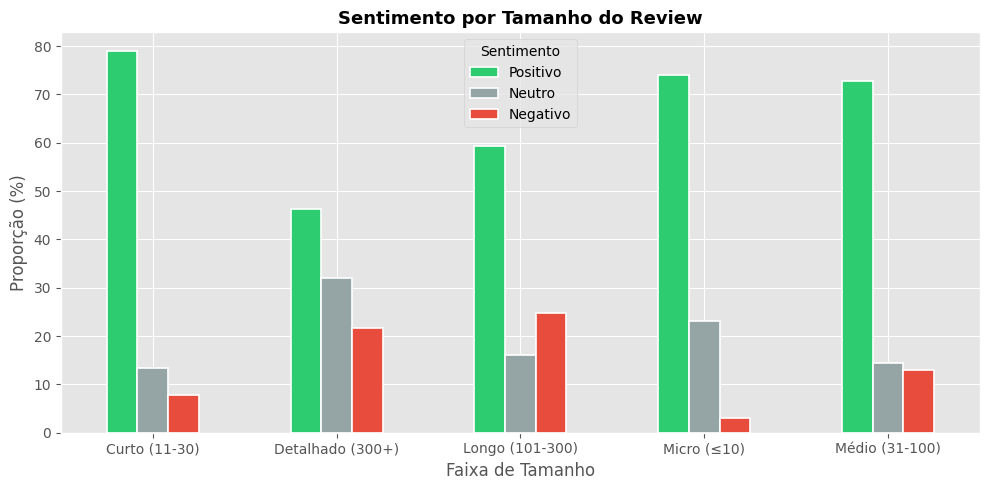

In [6]:
# Sentimento por faixa de tamanho 
cross_faixa = pd.crosstab(df['faixa_tamanho'], df['sentimento'], normalize='index')
cross_faixa = cross_faixa.reindex(columns=ordem) * 100

print("── Proporção de sentimentos por faixa de tamanho (%) ──\n")
print(cross_faixa.round(2))

ax = cross_faixa.plot(kind='bar', color=[cores_sentimento[s] for s in ordem],
                      figsize=(10, 5), edgecolor='white', linewidth=1.2, rot=0)
ax.set_title('Sentimento por Tamanho do Review', fontsize=13, fontweight='bold')
ax.set_ylabel('Proporção (%)')
ax.set_xlabel('Faixa de Tamanho')
ax.legend(title='Sentimento')
plt.tight_layout()
plt.savefig('../outputs/sentimento_por_faixa_tamanho.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Sentimento por Pesquisa -- Produtos Mais Amados e Mais Criticados

Analisamos as 43 categorias de pesquisa individualmente para identificar quais produtos geram mais satisfação e mais frustração nos consumidores brasileiros.

In [7]:
# Sentimento por pesquisa (as 43 individuais) 
cross_pesq = pd.crosstab(df['pesquisa'], df['sentimento'], normalize='index')
cross_pesq = cross_pesq.reindex(columns=ordem) * 100
cross_pesq['total_reviews'] = df['pesquisa'].value_counts()

# Filtrando pesquisas com pelo menos 100 reviews (evitar ruído estatístico)
cross_pesq = cross_pesq[cross_pesq['total_reviews'] >= 100]

# Top 10 mais negativos 
print("── TOP 10 PESQUISAS COM MAIOR NEGATIVIDADE ──\n")
top_neg = cross_pesq.sort_values('Negativo', ascending=False).head(10)
for i, (pesq, row) in enumerate(top_neg.iterrows(), 1):
    print(f"  {i:>2}. {pesq:<32} → {row['Negativo']:.1f}% neg | {row['Positivo']:.1f}% pos | ({int(row['total_reviews'])} reviews)")

# Top 10 mais positivos 
print(f"\n── TOP 10 PESQUISAS COM MAIOR POSITIVIDADE ──\n")
top_pos = cross_pesq.sort_values('Positivo', ascending=False).head(10)
for i, (pesq, row) in enumerate(top_pos.iterrows(), 1):
    print(f"  {i:>2}. {pesq:<32} → {row['Positivo']:.1f}% pos | {row['Negativo']:.1f}% neg | ({int(row['total_reviews'])} reviews)")

── TOP 10 PESQUISAS COM MAIOR NEGATIVIDADE ──

   1. drone                            → 30.5% neg | 45.1% pos | (213 reviews)
   2. smartwatch                       → 29.0% neg | 54.4% pos | (1532 reviews)
   3. aspirador                        → 27.7% neg | 53.8% pos | (632 reviews)
   4. ar-condicionado portatil         → 26.8% neg | 49.2% pos | (724 reviews)
   5. cadeira de escritorio            → 23.6% neg | 58.8% pos | (702 reviews)
   6. liquidificador                   → 23.3% neg | 58.3% pos | (506 reviews)
   7. camera digital                   → 21.3% neg | 42.2% pos | (422 reviews)
   8. console de videogame             → 20.3% neg | 58.6% pos | (227 reviews)
   9. aparelho de barbear eletrico     → 20.0% neg | 59.5% pos | (856 reviews)
  10. mochila                          → 19.7% neg | 65.1% pos | (4006 reviews)

── TOP 10 PESQUISAS COM MAIOR POSITIVIDADE ──

   1. fritadeira                       → 85.0% pos | 5.8% neg | (1225 reviews)
   2. monitor                     

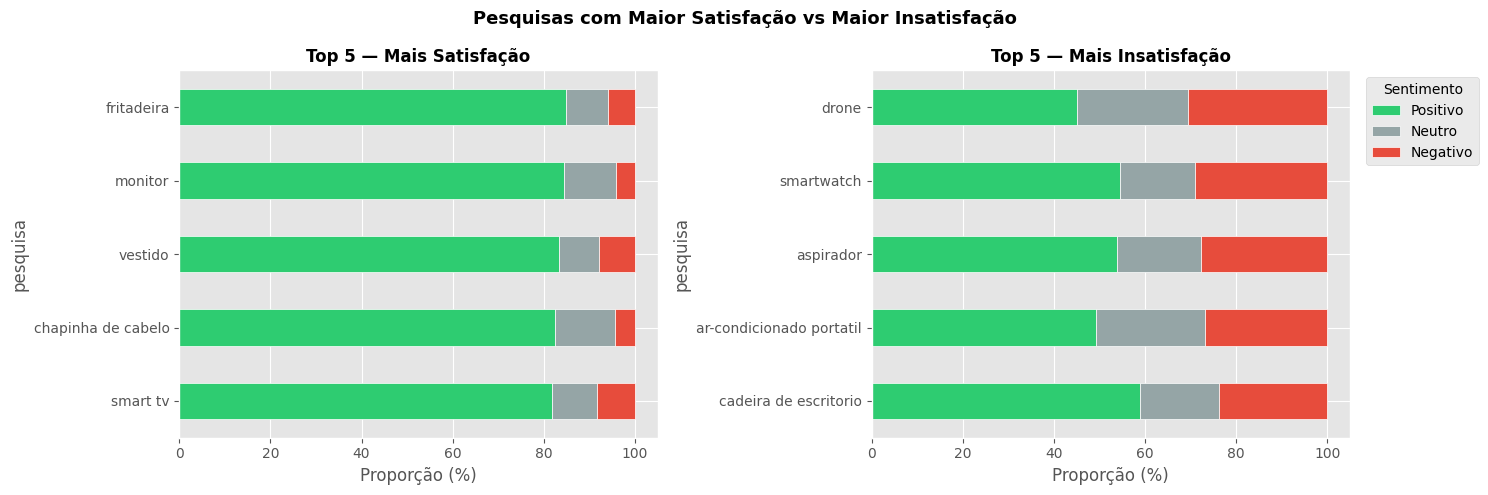

In [8]:
# Visualização: 5 mais positivos vs 5 mais negativos 
top5_pos = cross_pesq.sort_values('Positivo', ascending=False).head(5)
top5_neg = cross_pesq.sort_values('Negativo', ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mais positivos
top5_pos[['Positivo', 'Neutro', 'Negativo']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[cores_sentimento[s] for s in ordem], edgecolor='white')
axes[0].set_title('Top 5 — Mais Satisfação', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Proporção (%)')
axes[0].invert_yaxis()
axes[0].legend().remove()

# Mais negativos
top5_neg[['Positivo', 'Neutro', 'Negativo']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[cores_sentimento[s] for s in ordem], edgecolor='white')
axes[1].set_title('Top 5 — Mais Insatisfação', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Proporção (%)')
axes[1].invert_yaxis()
axes[1].legend(title='Sentimento', bbox_to_anchor=(1.02, 1))

plt.suptitle('Pesquisas com Maior Satisfação vs Maior Insatisfação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/top_bottom_pesquisas.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Nuvens de Palavras por Sentimento

Visualização das palavras mais frequentes nos reviews positivos, negativos e neutros sem pré-processamento pesado, para capturar a linguagem natural dos consumidores.

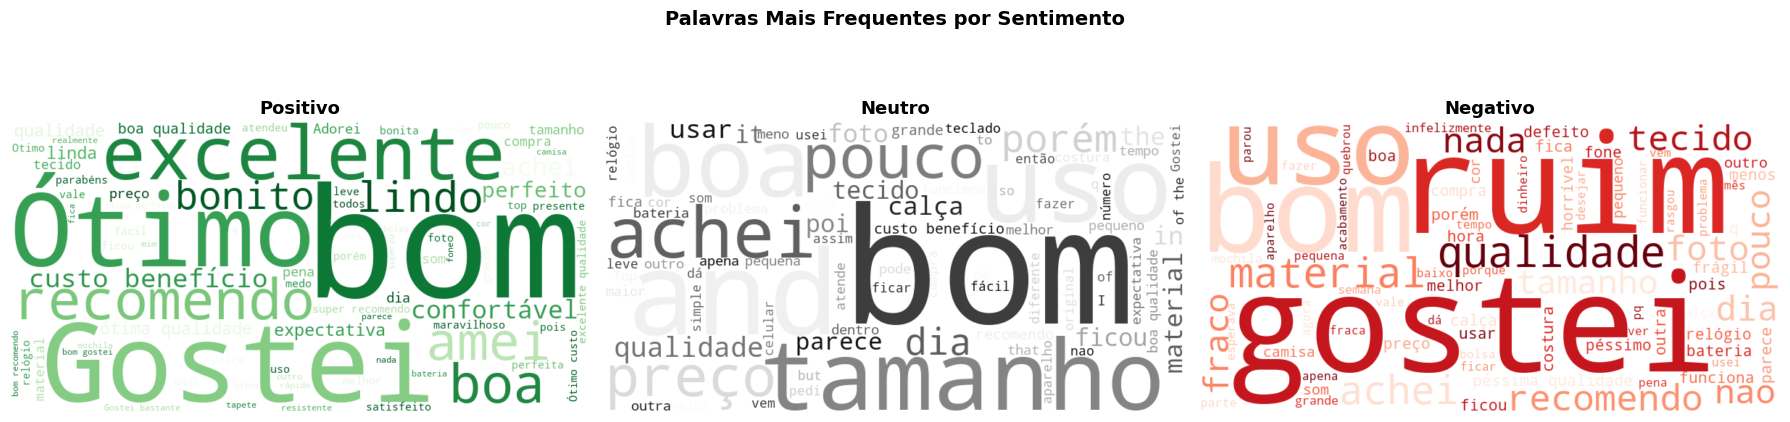

In [9]:
# Wordclouds por sentimento 
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Stopwords em português + palavras genéricas de review
stop_pt = set(stopwords.words('portuguese'))
stop_extras = {'produto', 'comprei', 'comprar', 'veio', 'chegou', 'ainda',
               'pra', 'pro', 'muito', 'mais', 'bem', 'não', 'sim', 'aqui',
               'esse', 'essa', 'este', 'esta', 'isso', 'tudo', 'todo', 'toda',
               'meu', 'minha', 'ter', 'vai', 'vou', 'faz', 'ser', 'está'}
stop_todas = stop_pt | stop_extras

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores_wc = {'Positivo': 'Greens', 'Neutro': 'Greys', 'Negativo': 'Reds'}

for i, sent in enumerate(ordem):
    texto = ' '.join(df[df['sentimento'] == sent]['review'].tolist())
    wc = WordCloud(
        width=800, height=400,
        max_words=80,
        stopwords=stop_todas,
        colormap=cores_wc[sent],
        background_color='white',
        collocations=True,
        min_font_size=8
    ).generate(texto)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{sent}', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Palavras Mais Frequentes por Sentimento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/wordclouds_sentimento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7.3 Análise dos Resultados

> Rankings -- os padrões fazem total sentido:

O top de satisfação é dominado por produtos com expectativa clara e entrega previsível: fritadeira (85% pos), monitor (84.3%), smart tv (81.9%). O consumidor sabe o que espera e o produto entrega. Já o top de insatisfação revela produtos com gap de expectativa: drone (30.5% neg produtos baratos que prometem qualidade profissional), smartwatch (29% neg relógios genéricos que imitam Apple Watch), ar-condicionado portátil (26.8% neg categoria que frequentemente não funciona como prometido). Esse padrão é ouro para o post: a insatisfação não vem do produto ruim, vem da promessa exagerada.

> Wordclouds -- validação forte do modelo:

Os vocabulários são genuinamente distintos entre sentimentos, o que confirma que a rotulação está coerente. Mas tem uma observação importante: "bom", "gostei" e "recomendo" aparecem nos 3 sentimentos. Isso acontece porque reviews negativos frequentemente usam essas palavras em contexto de negação ou concessão ("gostei do design, MAS...", "é bom, PORÉM quebrou"). Isso reforça por que usamos um modelo **BERT** (que `entende contexto`) em vez de um léxico simples (que contaria "bom" como positivo sempre).

---
# **Etapa 6: Pré-processamento de Texto**

## 8. Pré-processamento de Texto para Modelagem

Para transformar texto em features numéricas que alimentam os modelos de classificação, aplicamos um pipeline de NLP em português:

1. **Limpeza:** remoção de URLs, emojis, caracteres especiais, números
2. **Normalização:** lowercase, remoção de acentos
3. **Tokenização:** separação em palavras individuais
4. **Remoção de stopwords:** palavras sem carga semântica (de, para, com, etc.)
5. **Stemming:** redução das palavras ao radical (comprando -> compr, excelente -> excel)

> **Por que stemming e não lemmatization?**
> Stemming é mais agressivo (corta sufixos sem consultar dicionário) mas é significativamente mais rápido e suficiente para **Naive Bayes** + Bag of Words. Lemmatization (que retorna a forma canônica: "comprando" -> "comprar") seria mais adequado para modelos que dependem de semântica fina, como word embeddings. Para vetorização por contagem/TF-IDF, stemming é a escolha padrão.

In [10]:
# Imports para NLP 
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from unidecode import unidecode
import re

# Inicializar componentes
stemmer = RSLPStemmer()  # stemmer específico para português
stop_pt = set(stopwords.words('portuguese'))

# Stopwords customizadas - palavras genéricas de review que não diferenciam sentimento
stop_extras = {
    'produto', 'comprei', 'comprar', 'compra', 'veio', 'chegou', 'recebi',
    'pra', 'pro', 'tao', 'ja', 'ai', 'ne', 'la', 'vc', 'tb', 'tbm',
    'aqui', 'onde', 'assim', 'entao', 'ainda', 'tambem', 'depois',
    'porque', 'pois', 'ate', 'sobre', 'cada', 'outro', 'outra',
    'dia', 'dias', 'vez', 'vezes', 'ano', 'anos', 'mes',
    'amazon', 'mercado', 'livre', 'loja', 'vendedor', 'site'
}
stop_todas = stop_pt | stop_extras

print(f"Stopwords totais: {len(stop_todas)}")
print(f"Stemmer: RSLP (Removedor de Sufixos da Língua Portuguesa)")

# Testes do stemmer 
exemplos = ['excelente', 'péssimo', 'recomendo', 'comprando', 'qualidade', 
            'funcionando', 'quebrado', 'maravilhoso', 'horrível', 'entrega']
print(f"\n── Teste do stemmer RSLP ──")
for palavra in exemplos:
    print(f"  {palavra:<15} -> {stemmer.stem(palavra)}")

Stopwords totais: 250
Stemmer: RSLP (Removedor de Sufixos da Língua Portuguesa)

── Teste do stemmer RSLP ──
  excelente       -> excel
  péssimo         -> péss
  recomendo       -> recom
  comprando       -> compr
  qualidade       -> qual
  funcionando     -> funcion
  quebrado        -> quebr
  maravilhoso     -> maravilh
  horrível        -> horr
  entrega         -> entreg


In [11]:
# Função de pré-processamento de texto 
def preprocessar_texto(texto):
    """
    Pipeline completo de pré-processamento para NLP em pt-BR.
    Entrada: string bruta do review
    Saída: string limpa, sem acentos, stopwords removidas, stemmed
    """
    if not isinstance(texto, str):
        return ''
    
    # 1. Lowercase
    texto = texto.lower()
    
    # 2. Remover URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    
    # 3. Remover emojis e caracteres unicode especiais
    texto = re.sub(r'[^\w\s]', ' ', texto)
    
    # 4. Remover números
    texto = re.sub(r'\d+', '', texto)
    
    # 5. Remover acentos (após lowercase)
    texto = unidecode(texto)
    
    # 6. Tokenizar (split simples — suficiente para bag of words)
    tokens = texto.split()
    
    # 7. Remover stopwords + palavras com menos de 2 caracteres
    tokens = [t for t in tokens if t not in stop_todas and len(t) > 2]
    
    # 8. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    
    # 9. Remover tokens que ficaram com menos de 2 chars após stemming
    tokens = [t for t in tokens if len(t) > 2]
    
    return ' '.join(tokens)


# Teste com exemplos reais 
testes_preproc = [
    "Produto excelente, superou minhas expectativas! Recomendo demais 👍",
    "Péssimo, veio quebrado e o vendedor não respondeu. Nunca mais compro.",
    "É bom pelo preço, mas a qualidade poderia ser melhor...",
    "Mto top, recomendo dms",
]

print("── Teste do pipeline de pré-processamento ──\n")
for t in testes_preproc:
    resultado = preprocessar_texto(t)
    print(f"  Original:    \"{t}\"")
    print(f"  Processado:  \"{resultado}\"")
    print()

── Teste do pipeline de pré-processamento ──

  Original:    "Produto excelente, superou minhas expectativas! Recomendo demais 👍"
  Processado:  "excel super expect recom demal"

  Original:    "Péssimo, veio quebrado e o vendedor não respondeu. Nunca mais compro."
  Processado:  "pess quebr nao respond nunc compr"

  Original:    "É bom pelo preço, mas a qualidade poderia ser melhor..."
  Processado:  "bom prec qual pod melhor"

  Original:    "Mto top, recomendo dms"
  Processado:  "mto top recom"



In [12]:
# Aplicação do pré-processamento em todo o dataset 
print(f"Pré-processando {len(df)} reviews...")
inicio = time.time()

df['review_processado'] = df['review'].apply(preprocessar_texto)

tempo = time.time() - inicio
print(f"Concluído em {tempo:.1f}s ({len(df)/tempo:.0f} reviews/segundo)")

# Verificação 
# Reviews que ficaram vazios após processamento
vazios_pos = (df['review_processado'] == '') | (df['review_processado'].isna())
print(f"\nReviews vazios após processamento: {vazios_pos.sum()} ({vazios_pos.sum()/len(df)*100:.2f}%)")

# Comparação de comprimento
df['len_processado'] = df['review_processado'].str.len()
print(f"\n── Comprimento médio ──")
print(f"  Original:    {df['len_review'].mean():.1f} chars")
print(f"  Processado:  {df['len_processado'].mean():.1f} chars")
print(f"  Redução:     {(1 - df['len_processado'].mean()/df['len_review'].mean())*100:.1f}%")

# Exemplos lado a lado
print(f"\n── Exemplos (original -> processado) ──")
amostra = df.sample(5, random_state=42)
for _, row in amostra.iterrows():
    print(f"  [{row['sentimento']}]")
    print(f"    Original:   \"{row['review'][:100]}\"")
    print(f"    Processado: \"{row['review_processado'][:100]}\"")
    print()

Pré-processando 68033 reviews...
Concluído em 28.3s (2404 reviews/segundo)

Reviews vazios após processamento: 111 (0.16%)

── Comprimento médio ──
  Original:    84.9 chars
  Processado:  43.3 chars
  Redução:     48.9%

── Exemplos (original -> processado) ──
  [Negativo]
    Original:   "Muito pequena,não oferece nenhuma segurança e o material é frágil. Não gostei!."
    Processado: "pequen nao oferec nenhum seguranc mater fragil nao gost"

  [Neutro]
    Original:   "No dia que usei já quebrou."
    Processado: "use quebr"

  [Positivo]
    Original:   "A mídia não pôde ser carregada.
                



 Modelo ótimo !Super leve e confortável.Parece q"
    Processado: "mid nao pod carreg model otim sup lev conforta parec orig bem rap recom"

  [Positivo]
    Original:   "Produto de altissima qualidade. Recomendo."
    Processado: "altiss qual recom"

  [Positivo]
    Original:   "Boa qualidade de som."
    Processado: "boa qual som"



In [13]:
# Decisão sobre reviews vazios pós-processamento 
if vazios_pos.sum() > 0:
    print(f"Removendo {vazios_pos.sum()} reviews que ficaram vazios após processamento...")
    print(f"Exemplos dos removidos:")
    print(df[vazios_pos]['review'].head(10).tolist())
    df = df[~vazios_pos].copy()
    print(f"\nShape final: {df.shape}")
else:
    print("Nenhum review ficou vazio -- todos preservados.")

print(f"\n── Distribuição de sentimentos (pós-processamento) ──")
print(df['sentimento'].value_counts())

Removendo 111 reviews que ficaram vazios após processamento...
Exemplos dos removidos:
['Produto ok', '100%', 'Diariamente', 'No dia a dia', 'Dá para usar.', 'Ele é ok', '👏🏼👏🏼👏🏼👏🏼👏🏼👏🏼.', 'Trava muito.', 'Veio usado.', 'Xx.']

Shape final: (67922, 13)

── Distribuição de sentimentos (pós-processamento) ──
sentimento
Positivo    47923
Neutro      10509
Negativo     9490
Name: count, dtype: int64


In [14]:
# ----------------------------------- Checkpoint pós-processamento de texto -----------------------------------------------------------------
df.to_csv('../dados/df_checkpoint_preprocessado.csv', index=False, encoding='utf-8-sig', sep=';')
print(f"Checkpoint salvo: {df.shape}")
print(f"  Colunas: {df.columns.tolist()}")

Checkpoint salvo: (67922, 13)
  Colunas: ['pesquisa', 'titulo_produto', 'link', 'review', 'plataforma', 'len_review', 'categoria', 'n_palavras', 'faixa_tamanho', 'sentimento', 'confianca', 'review_processado', 'len_processado']


# **Etapa 7: Vetorização + Split Treino/Teste**

## 9. Vetorização e Preparação para Modelagem

### Split Treino/Teste
A divisão é feita **antes** da vetorização para evitar data leakage o vocabulário e os pesos TF-IDF devem ser aprendidos exclusivamente nos dados de treino.

### Duas estratégias de vetorização
Treinaremos os modelos com ambas para comparar:

1. **CountVectorizer (Bag of Words):** conta a frequência absoluta de cada palavra. Simples, interpretável, baseline natural.
2. **TF-IDF (Term Frequency — Inverse Document Frequency):** pondera a frequência pela raridade do termo no corpus. Palavras que aparecem em muitos documentos recebem peso menor. Captura melhor a importância discriminativa de cada termo.

### Por que Naive Bayes precisa de vetorização
Os algoritmos Naive Bayes operam sobre vetores numéricos não processam texto. Cada review vira um vetor onde cada posição representa uma palavra do vocabulário e o valor representa sua frequência (BoW) ou importância (TF-IDF).

In [15]:
# Split treino/teste 
from sklearn.model_selection import train_test_split

X = df['review_processado']
y = df['sentimento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserva proporção das classes
)

print(f"── Split Treino/Teste ──")
print(f"  Treino: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Teste:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n── Proporção das classes (stratify) ──")
print(f"  Treino:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print(f"\n  Teste:")
print((y_test.value_counts(normalize=True) * 100).round(2))

── Split Treino/Teste ──
  Treino: 54337 (80.0%)
  Teste:  13585 (20.0%)

── Proporção das classes (stratify) ──
  Treino:
sentimento
Positivo   70.56
Neutro     15.47
Negativo   13.97
Name: proportion, dtype: float64

  Teste:
sentimento
Positivo   70.56
Neutro     15.47
Negativo   13.97
Name: proportion, dtype: float64


In [16]:
# Vetorização 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. CountVectorizer (Bag of Words) 
# fit no treino, transform em ambos - sem leakage
bow_vectorizer = CountVectorizer(
    max_features=10000,   # top 10k palavras mais frequentes
    min_df=5,             # ignorar palavras que aparecem em < 5 reviews
    max_df=0.95,          # ignorar palavras que aparecem em > 95% dos reviews
    ngram_range=(1, 2)    # unigramas + bigramas (ex: "nao recom", "boa qual")
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"── CountVectorizer (Bag of Words) ──")
print(f"  Vocabulário: {len(bow_vectorizer.vocabulary_)} termos")
print(f"  X_train: {X_train_bow.shape}")
print(f"  X_test:  {X_test_bow.shape}")
print(f"  Sparsity: {(1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]))*100:.2f}%")

# 2. TF-IDF 
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True     # aplica log(1+tf) — suaviza diferenças de frequência
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"\n── TF-IDF Vectorizer ──")
print(f"  Vocabulário: {len(tfidf_vectorizer.vocabulary_)} termos")
print(f"  X_train: {X_train_tfidf.shape}")
print(f"  X_test:  {X_test_tfidf.shape}")
print(f"  Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

── CountVectorizer (Bag of Words) ──
  Vocabulário: 10000 termos
  X_train: (54337, 10000)
  X_test:  (13585, 10000)
  Sparsity: 99.90%

── TF-IDF Vectorizer ──
  Vocabulário: 10000 termos
  X_train: (54337, 10000)
  X_test:  (13585, 10000)
  Sparsity: 99.90%


In [17]:
# Top termos mais frequentes no vocabulário 
import numpy as np

# BoW - termos com maior frequência total no treino
freq_total = np.array(X_train_bow.sum(axis=0)).flatten()
termos_bow = bow_vectorizer.get_feature_names_out()
top_idx = freq_total.argsort()[::-1][:20]

print("── Top 20 termos mais frequentes (BoW) ──\n")
for i in top_idx:
    print(f"  {termos_bow[i]:<25} → {int(freq_total[i]):>6} ocorrências")

# Exemplos de bigramas capturados 
bigramas = [t for t in termos_bow if ' ' in t]
print(f"\n── Bigramas no vocabulário: {len(bigramas)} ──")
# Mostrar bigramas mais frequentes
freq_bi = {t: freq_total[bow_vectorizer.vocabulary_[t]] for t in bigramas}
top_bi = sorted(freq_bi.items(), key=lambda x: x[1], reverse=True)[:15]
print("Top 15 bigramas:")
for termo, freq in top_bi:
    print(f"  {termo:<25} -> {int(freq):>5}")

── Top 20 termos mais frequentes (BoW) ──

  nao                       →  15887 ocorrências
  bom                       →  12769 ocorrências
  otim                      →   8975 ocorrências
  qual                      →   8113 ocorrências
  gost                      →   7256 ocorrências
  bem                       →   6579 ocorrências
  recom                     →   6069 ocorrências
  fic                       →   5774 ocorrências
  boa                       →   5351 ocorrências
  excel                     →   5284 ocorrências
  perfeit                   →   4796 ocorrências
  lind                      →   4254 ocorrências
  sup                       →   3327 ocorrências
  ach                       →   3195 ocorrências
  tamanh                    →   3139 ocorrências
  bonit                     →   3095 ocorrências
  val                       →   3017 ocorrências
  ame                       →   2934 ocorrências
  pouc                      →   2695 ocorrências
  cust                    

## 9.1 Diagnóstico da Vetorização

Resultados impecáveis. Split estratificado preservou as proporções, vocabulário atingiu o teto de 10k termos, sparsity de 99.90% (normal), e os bigramas são exatamente o que precisamos: "nao gost", "nao recom", "cust benefici", "val pen". Esses bigramas capturam sentimento muito melhor que unigramas isolados.

---
# **ETAPA 8: Modelagem --> `Naive Bayes` + `Logistic Regression`**


## 10. Modelagem -- Treinamento e Avaliação

### Modelos avaliados
- **MultinomialNB:** Naive Bayes para dados de contagem/frequência. Natural para BoW e TF-IDF. Assume que as features representam contagens ou frequências de termos.
- **BernoulliNB:** Naive Bayes para dados binários (presença/ausência do termo). Penaliza explicitamente a *ausência* de termos — útil quando "não conter uma palavra" é informativo.
- **ComplementNB:** Variante do Multinomial projetada especificamente para datasets desbalanceados. Calcula os parâmetros usando o *complemento* de cada classe, reduzindo o viés para a classe majoritária.
- **Logistic Regression:** Baseline discriminativo. Diferente dos Naive Bayes (generativos), a regressão logística modela diretamente a fronteira de decisão entre as classes.

> **Por que não GaussianNB?**
> O GaussianNB assume que as features seguem distribuição normal (Gaussiana). Matrizes esparsas de texto (99.9% de zeros) violam essa premissa drasticamente. A maioria dos valores é zero, o que não é uma distribuição normal. GaussianNB tende a performar mal em texto e exigiria converter a matriz esparsa para densa, consumindo ~5GB de RAM (54k × 10k × 8 bytes). Os três NB acima são os adequados para vetorização de texto.

### Métricas de avaliação
- **Accuracy:** proporção geral de acertos (referência, não métrica principal)
- **Precision:** dos que o modelo disse ser X, quantos realmente são X
- **Recall:** dos que realmente são X, quantos o modelo encontrou
- **F1-Score:** média harmônica entre Precision e Recall
- **Macro Avg:** média simples das métricas por classe trata todas as classes com peso igual, independente do tamanho

> Métrica diferencial: 
A **Macro Avg F1** é a métrica principal de comparação, pois penaliza igualmente o erro nas 3 classes evitando que o modelo "ganhe" acertando só a classe majoritária (Positivo).

In [18]:
# Imports 
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# Definição dos modelos 
modelos = {
    'MultinomialNB'     : MultinomialNB(alpha=1.0),
    'BernoulliNB'       : BernoulliNB(alpha=1.0),
    'ComplementNB'      : ComplementNB(alpha=1.0),
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',    # compensa desbalanceamento
        random_state=42,
        solver='lbfgs',
        n_jobs=-1
    )
}

# Definição dos datasets de vetorização 
datasets = {
    'BoW'   : (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}

# Treinamento e avaliação de todas as combinações 
resultados = []

for nome_vec, (X_tr, X_te) in datasets.items():
    for nome_modelo, modelo in modelos.items():
        print(f"\n{'='*55}")
        print(f"  {nome_modelo} + {nome_vec}")
        print(f"{'='*55}")
        
        inicio = time.time()
        modelo.fit(X_tr, y_train)
        tempo_treino = time.time() - inicio
        
        y_pred = modelo.predict(X_te)
        
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        print(f"  Tempo de treino: {tempo_treino:.2f}s")
        print(f"  Accuracy: {acc:.4f}")
        print(f"\n{classification_report(y_test, y_pred)}")
        
        resultados.append({
            'Modelo'        : nome_modelo,
            'Vetorização'   : nome_vec,
            'Accuracy'      : round(acc, 4),
            'Macro Precision': round(report['macro avg']['precision'], 4),
            'Macro Recall'  : round(report['macro avg']['recall'], 4),
            'Macro F1'      : round(report['macro avg']['f1-score'], 4),
            'F1 Positivo'   : round(report['Positivo']['f1-score'], 4),
            'F1 Neutro'     : round(report['Neutro']['f1-score'], 4),
            'F1 Negativo'   : round(report['Negativo']['f1-score'], 4),
            'Tempo (s)'     : round(tempo_treino, 2)
        })

print(f"\n{len(resultados)} combinações treinadas e avaliadas")


  MultinomialNB + BoW
  Tempo de treino: 0.31s
  Accuracy: 0.8263

              precision    recall  f1-score   support

    Negativo       0.66      0.84      0.74      1898
      Neutro       0.58      0.27      0.36      2102
    Positivo       0.89      0.95      0.92      9585

    accuracy                           0.83     13585
   macro avg       0.71      0.68      0.67     13585
weighted avg       0.81      0.83      0.81     13585


  BernoulliNB + BoW
  Tempo de treino: 0.46s
  Accuracy: 0.7935

              precision    recall  f1-score   support

    Negativo       0.68      0.72      0.70      1898
      Neutro       0.46      0.28      0.35      2102
    Positivo       0.85      0.92      0.89      9585

    accuracy                           0.79     13585
   macro avg       0.67      0.64      0.64     13585
weighted avg       0.77      0.79      0.78     13585


  ComplementNB + BoW
  Tempo de treino: 0.21s
  Accuracy: 0.8253

              precision    recall  f1

In [19]:
# Tabela comparativa de resultados 
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print("=" * 80)
print("RANKING DE MODELOS — ORDENADO POR MACRO F1")
print("=" * 80)
print()
print(df_resultados.to_string(index=False))

# Melhor modelo 
melhor = df_resultados.iloc[0]
print(f"\n{'='*55}")
print(f"     MELHOR MODELO: {melhor['Modelo']} + {melhor['Vetorização']}")
print(f"     Macro F1: {melhor['Macro F1']}")
print(f"     Accuracy: {melhor['Accuracy']}")
print(f"{'='*55}")

RANKING DE MODELOS — ORDENADO POR MACRO F1

            Modelo Vetorização  Accuracy  Macro Precision  Macro Recall  Macro F1  F1 Positivo  F1 Neutro  F1 Negativo  Tempo (s)
LogisticRegression         BoW      0.82             0.74          0.78      0.75         0.91       0.59         0.75       7.78
LogisticRegression      TF-IDF      0.81             0.73          0.78      0.74         0.89       0.57         0.76       5.71
      ComplementNB      TF-IDF      0.81             0.68          0.73      0.69         0.91       0.46         0.71       0.29
     MultinomialNB      TF-IDF      0.83             0.74          0.66      0.68         0.91       0.37         0.75       0.22
     MultinomialNB         BoW      0.83             0.71          0.68      0.67         0.92       0.36         0.74       0.31
      ComplementNB         BoW      0.83             0.71          0.70      0.67         0.92       0.38         0.72       0.21
       BernoulliNB         BoW      0.79      

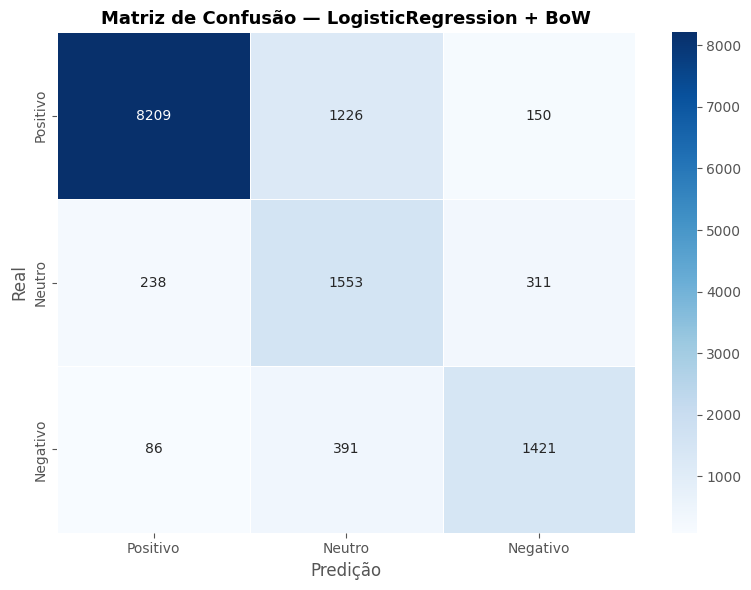


── Erros mais comuns ──
  Positivo classificado como Neutro:  1226
  Positivo classificado como Negativo: 150
  Neutro classificado como Positivo:  238
  Neutro classificado como Negativo:  311
  Negativo classificado como Positivo: 86
  Negativo classificado como Neutro:  391


In [20]:
# Retreinando o melhor modelo para gerar a matriz de confusão 
# Identificando vetorização e modelo vencedor
vec_melhor = melhor['Vetorização']
mod_melhor = melhor['Modelo']

X_tr_melhor = datasets[vec_melhor][0]
X_te_melhor = datasets[vec_melhor][1]

modelo_final = modelos[mod_melhor]
modelo_final.fit(X_tr_melhor, y_train)
y_pred_final = modelo_final.predict(X_te_melhor)

# Matriz de confusão 
cm = confusion_matrix(y_test, y_pred_final, labels=ordem)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordem, yticklabels=ordem, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel('Predição', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusão — {mod_melhor} + {vec_melhor}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/matriz_confusao_melhor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise dos erros mais comuns 
print(f"\n── Erros mais comuns ──")
print(f"  Positivo classificado como Neutro:  {cm[0][1]}")
print(f"  Positivo classificado como Negativo: {cm[0][2]}")
print(f"  Neutro classificado como Positivo:  {cm[1][0]}")
print(f"  Neutro classificado como Negativo:  {cm[1][2]}")
print(f"  Negativo classificado como Positivo: {cm[2][0]}")
print(f"  Negativo classificado como Neutro:  {cm[2][1]}")

## 10.1 Diagnóstico dos Modelos - Baseline

#### Resultado geral
A **Logistic Regression + BoW** liderou o ranking com Macro F1 de 0.75, superando o segundo colocado (ComplementNB + TF-IDF, Macro F1 0.69) por uma margem significativa. A diferença é especialmente notável no F1 da classe Neutro: 0.59 (LR) vs 0.46 (CNB), indicando que a Logistic Regression modela a fronteira entre classes com muito mais precisão que a premissa de independência dos Naive Bayes.

#### O gargalo: classe Neutro
Todos os 8 modelos sofrem na classe Neutro, com F1 variando entre 0.35 e 0.59. Isso é esperado e coerente com a natureza do problema: "neutro" é a zona de transição natural entre positivo e negativo. O erro mais comum na matriz de confusão confirma isso: 1.226 reviews positivos foram classificados como neutro, evidenciando que a fronteira positivo/neutro é linguisticamente difusa.

#### Naive Bayes vs Logistic Regression
Os modelos Naive Bayes apresentaram accuracy competitiva (0.79 a 0.83), mas Macro F1 consistentemente inferior (0.64 a 0.69). Isso ocorre porque o NB maximiza o acerto na classe majoritária (Positivo, com F1 de 0.89 a 0.92) às custas das minoritárias. A Logistic Regression, com `class_weight='balanced'`, distribui o esforço de forma mais equilibrada entre as 3 classes.

#### BoW vs TF-IDF
A diferença entre vetorizações foi pequena. BoW venceu marginalmente na maioria das combinações, sugerindo que para este dataset a frequência bruta dos termos já carrega informação discriminativa suficiente. O TF-IDF, que penaliza termos muito comuns, não agregou valor significativo, possivelmente porque o pré-processamento (stopwords, stemming) já havia removido os termos genéricos.

#### Decisão: otimizar os 3 melhores
Com base nos resultados, selecionamos os 3 melhores modelos para otimização de hiperparâmetros via GridSearchCV:
1. LogisticRegression + BoW (Macro F1: 0.75)
2. LogisticRegression + TF-IDF (Macro F1: 0.74)
3. ComplementNB + TF-IDF (Macro F1: 0.69)

O objetivo é verificar se ajustes no regularizador (C) da LR e no suavizador (alpha) do CNB c

---
# **Etapa 8.1: `Otimização de Hiperparâmetros`**

### 10.2 Otimização de Hiperparâmetros

Aplicamos **GridSearchCV** com validação cruzada estratificada (5 folds) nos 3 melhores modelos para buscar a combinação de hiperparâmetros que maximiza o **Macro F1**.

Modelos otimizados:
1. **LogisticRegression + BoW** (1º lugar | Macro F1: 0.75)
2. **LogisticRegression + TF-IDF** (2º lugar | Macro F1: 0.74)
3. **ComplementNB + TF-IDF** (3º lugar | Macro F1: 0.69)

In [21]:
# Otimização de hiperparâmetros 
from sklearn.model_selection import GridSearchCV

# 1. LogisticRegression + BoW 
print("=" * 55)
print("  Otimizando: LogisticRegression + BoW")
print("=" * 55)

param_grid_lr = {
    'C': [0.1, 0.5, 1.0, 5.0, 10.0],
    'class_weight': ['balanced', None],
    'solver': ['lbfgs', 'liblinear']
}

gs_lr_bow = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
gs_lr_bow.fit(X_train_bow, y_train)
tempo_lr_bow = time.time() - inicio

print(f"\n  Tempo: {tempo_lr_bow/60:.1f} min")
print(f"  Melhor Macro F1 (CV): {gs_lr_bow.best_score_:.4f}")
print(f"  Melhores parâmetros: {gs_lr_bow.best_params_}")

# 2. LogisticRegression + TF-IDF 
print(f"\n{'=' * 55}")
print("  Otimizando: LogisticRegression + TF-IDF")
print("=" * 55)

gs_lr_tfidf = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
gs_lr_tfidf.fit(X_train_tfidf, y_train)
tempo_lr_tfidf = time.time() - inicio

print(f"\n  Tempo: {tempo_lr_tfidf/60:.1f} min")
print(f"  Melhor Macro F1 (CV): {gs_lr_tfidf.best_score_:.4f}")
print(f"  Melhores parâmetros: {gs_lr_tfidf.best_params_}")

# 3. ComplementNB + TF-IDF 
print(f"\n{'=' * 55}")
print("  Otimizando: ComplementNB + TF-IDF")
print("=" * 55)

param_grid_cnb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'norm': [True, False]
}

gs_cnb_tfidf = GridSearchCV(
    ComplementNB(),
    param_grid_cnb,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
gs_cnb_tfidf.fit(X_train_tfidf, y_train)
tempo_cnb = time.time() - inicio

print(f"\n  Tempo: {tempo_cnb/60:.1f} min")
print(f"  Melhor Macro F1 (CV): {gs_cnb_tfidf.best_score_:.4f}")
print(f"  Melhores parâmetros: {gs_cnb_tfidf.best_params_}")

  Otimizando: LogisticRegression + BoW
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Tempo: 1.2 min
  Melhor Macro F1 (CV): 0.7659
  Melhores parâmetros: {'C': 0.5, 'class_weight': None, 'solver': 'lbfgs'}

  Otimizando: LogisticRegression + TF-IDF
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Tempo: 0.7 min
  Melhor Macro F1 (CV): 0.7587
  Melhores parâmetros: {'C': 1.0, 'class_weight': None, 'solver': 'lbfgs'}

  Otimizando: ComplementNB + TF-IDF
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Tempo: 0.1 min
  Melhor Macro F1 (CV): 0.6912
  Melhores parâmetros: {'alpha': 0.1, 'norm': False}


In [22]:
# Avaliando os 3 modelos otimizados no conjunto de teste 
modelos_otimizados = {
    'LR + BoW (tuned)'     : (gs_lr_bow.best_estimator_, X_test_bow),
    'LR + TF-IDF (tuned)'  : (gs_lr_tfidf.best_estimator_, X_test_tfidf),
    'CNB + TF-IDF (tuned)' : (gs_cnb_tfidf.best_estimator_, X_test_tfidf),
}

resultados_tuned = []

for nome, (modelo, X_te) in modelos_otimizados.items():
    y_pred = modelo.predict(X_te)
    report = classification_report(y_test, y_pred, output_dict=True)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*55}")
    print(f"  {nome}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred))
    
    resultados_tuned.append({
        'Modelo'        : nome,
        'Accuracy'      : round(acc, 4),
        'Macro F1'      : round(report['macro avg']['f1-score'], 4),
        'F1 Positivo'   : round(report['Positivo']['f1-score'], 4),
        'F1 Neutro'     : round(report['Neutro']['f1-score'], 4),
        'F1 Negativo'   : round(report['Negativo']['f1-score'], 4),
    })

# Tabela comparativa: antes vs depois do tuning 
df_tuned = pd.DataFrame(resultados_tuned).sort_values('Macro F1', ascending=False)

print(f"\n{'='*70}")
print("RANKING PÓS-OTIMIZAÇÃO")
print(f"{'='*70}")
print(df_tuned.to_string(index=False))

# Comparação com baseline (antes do tuning) 
melhor_antes = 0.7491  # LR + BoW baseline
melhor_depois = df_tuned.iloc[0]['Macro F1']
delta = melhor_depois - melhor_antes

print(f"\n── Impacto da otimização ──")
print(f"  Macro F1 antes:  {melhor_antes:.4f}")
print(f"  Macro F1 depois: {melhor_depois:.4f}")
print(f"  Delta:           {delta:+.4f} ({delta/melhor_antes*100:+.2f}%)")


  LR + BoW (tuned)
              precision    recall  f1-score   support

    Negativo       0.81      0.72      0.76      1898
      Neutro       0.62      0.56      0.59      2102
    Positivo       0.92      0.95      0.93      9585

    accuracy                           0.86     13585
   macro avg       0.78      0.74      0.76     13585
weighted avg       0.85      0.86      0.86     13585


  LR + TF-IDF (tuned)
              precision    recall  f1-score   support

    Negativo       0.81      0.73      0.77      1898
      Neutro       0.62      0.52      0.57      2102
    Positivo       0.91      0.96      0.93      9585

    accuracy                           0.86     13585
   macro avg       0.78      0.74      0.76     13585
weighted avg       0.85      0.86      0.85     13585


  CNB + TF-IDF (tuned)
              precision    recall  f1-score   support

    Negativo       0.60      0.88      0.72      1898
      Neutro       0.52      0.42      0.46      2102
    Posi

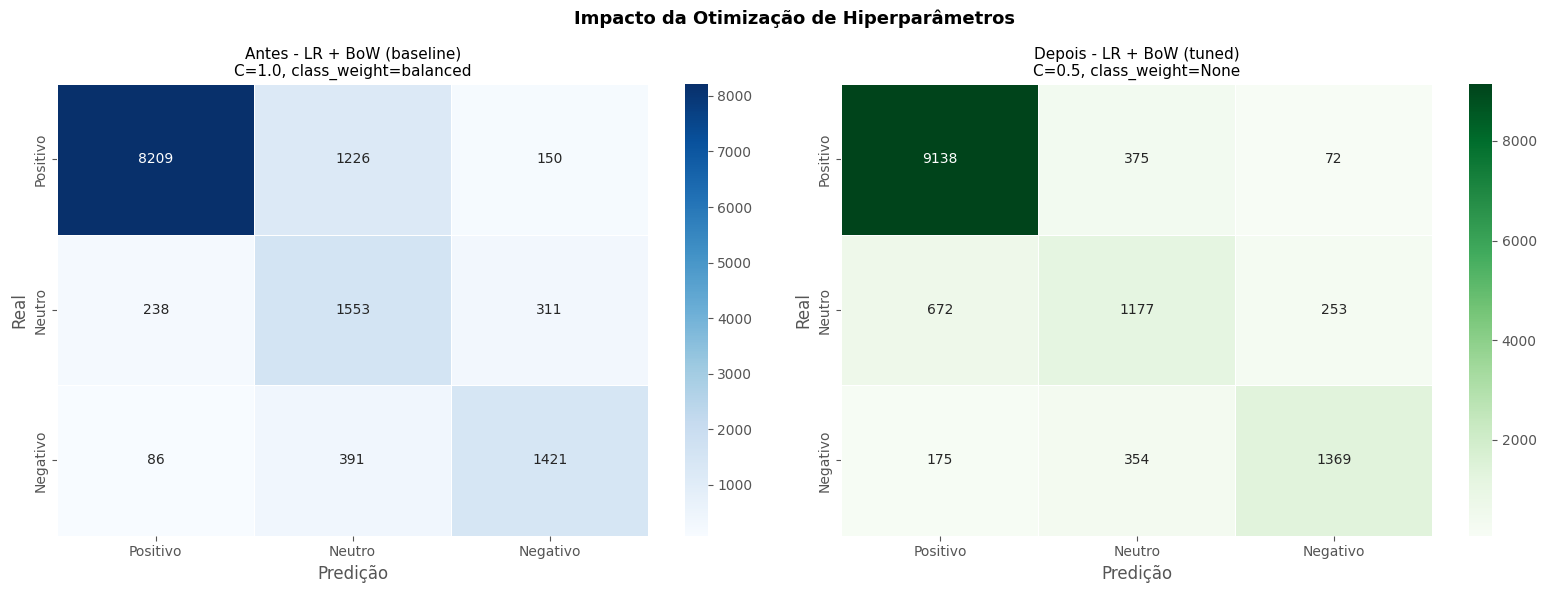


-- Diferença (Tuned - Baseline) --
  Positivo na diagonal = mais acertos
  Negativo fora da diagonal = menos erros

          Positivo  Neutro  Negativo
Positivo       929    -851       -78
Neutro         434    -376       -58
Negativo        89     -37       -52


In [23]:
# Recriando a matriz do baseline para comparação
## Retreinando o LR + BoW com parâmetros originais (baseline)
modelo_baseline = LogisticRegression(
    C=1.0, 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42, 
    solver='lbfgs'
)
modelo_baseline.fit(X_train_bow, y_train)
y_pred_baseline = modelo_baseline.predict(X_test_bow)
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=ordem)

## Gerando predições do modelo otimizado
y_pred_tuned = gs_lr_bow.best_estimator_.predict(X_test_bow)
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=ordem)

## Plotando as duas matrizes lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordem, yticklabels=ordem, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Real')
axes[0].set_title('Antes - LR + BoW (baseline)\nC=1.0, class_weight=balanced', fontsize=11)

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=ordem, yticklabels=ordem, ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Real')
axes[1].set_title('Depois - LR + BoW (tuned)\nC=0.5, class_weight=None', fontsize=11)

plt.suptitle('Impacto da Otimização de Hiperparâmetros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/comparacao_antes_depois_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## Diferença entre as matrizes (positivo na diagonal = melhoria)
diff = cm_tuned - cm_baseline
print("\n-- Diferença (Tuned - Baseline) --")
print("  Positivo na diagonal = mais acertos")
print("  Negativo fora da diagonal = menos erros\n")
print(pd.DataFrame(diff, index=ordem, columns=ordem))

## 10.3 Diagnóstico da Otimização

#### Impacto do tuning
A otimização elevou o `Macro F1` de 0.749 para 0.761 (+1.62%). Embora o ganho percentual pareça modesto, o impacto qualitativo é relevante: a `accuracy` subiu de 0.82 para 0.86, e o `F1` do Positivo alcançou 0.93 (vs 0.91 no baseline).

#### Hiperparâmetros vencedores
- **LR + BoW:** `C=0.5`, `class_weight=None`, `solver='lbfgs'`
- **LR + TF-IDF:** `C=1.0`, `class_weight=None`, `solver='lbfgs'`

Resultado surpreendente: `class_weight=None` superou `class_weight='balanced'`. Isso indica que o desbalanceamento do dataset (70/16/14) não é severo o suficiente para justificar a compensação artificial. O modelo performa melhor aprendendo a distribuição natural das classes do que forçando equilíbrio.

O valor de `C=0.5` (abaixo do default 1.0) in

---
# **Etapa 9: Análise de Erros + Palavras Mais Frequentes**

## 11. Análise de Erros e Interpretabilidade

Investigar onde o modelo erra é tão importante quanto medir onde acerta. A análise de erros revela:
- Padrões linguísticos que confundem o classificador
- Limitações estruturais do pipeline (stemming agressivo, reviews curtos)
- Oportunidades de melhoria para iterações futuras

In [25]:
# Criando DataFrame com predições para análise detalhada
## Montando a base de erros com contexto completo
df_teste = df.loc[X_test.index].copy()
df_teste['predicao'] = y_pred_tuned
df_teste['acertou'] = df_teste['sentimento'] == df_teste['predicao']

print(f"-- Resumo geral --")
print(f"  Acertos: {df_teste['acertou'].sum()} ({df_teste['acertou'].mean()*100:.2f}%)")
print(f"  Erros:   {(~df_teste['acertou']).sum()} ({(~df_teste['acertou']).mean()*100:.2f}%)")

# Analisando erros por tipo de confusão
## Categorizando cada tipo de erro
erros = df_teste[~df_teste['acertou']].copy()
erros['tipo_erro'] = erros['sentimento'] + ' -> ' + erros['predicao']

print(f"\n-- Distribuição dos tipos de erro --\n")
tipo_erro_dist = erros['tipo_erro'].value_counts()
for tipo, count in tipo_erro_dist.items():
    print(f"  {tipo:<30} {count:>5} ({count/len(erros)*100:.1f}%)")

-- Resumo geral --
  Acertos: 11684 (86.01%)
  Erros:   1901 (13.99%)

-- Distribuição dos tipos de erro --

  Neutro -> Positivo               672 (35.3%)
  Positivo -> Neutro               375 (19.7%)
  Negativo -> Neutro               354 (18.6%)
  Neutro -> Negativo               253 (13.3%)
  Negativo -> Positivo             175 (9.2%)
  Positivo -> Negativo              72 (3.8%)


In [26]:
# Examinando exemplos reais dos 3 tipos de erro mais frequentes
## Selecionando amostras representativas de cada tipo

tipos_top3 = tipo_erro_dist.head(3).index.tolist()

for tipo in tipos_top3:
    print(f"\n{'='*55}")
    print(f"  {tipo}")
    print(f"{'='*55}")
    
    amostra = erros[erros['tipo_erro'] == tipo].sample(
        min(5, len(erros[erros['tipo_erro'] == tipo])), 
        random_state=42
    )
    
    for _, row in amostra.iterrows():
        conf = row['confianca']
        faixa = row['faixa_tamanho']
        print(f"\n  [{faixa} | confiança rotulação: {conf:.3f}]")
        print(f"  \"{row['review'][:150]}\"")


  Neutro -> Positivo

  [Curto (11-30) | confiança rotulação: 0.683]
  "Chego certinho."

  [Longo (101-300) | confiança rotulação: 0.533]
  "O produto é o que esperava custo benefício recomendo.
Agora tome cuidado no tamanho foi necessário comprar 3 vezes. Primeira vez tamanha m veio pequen"

  [Médio (31-100) | confiança rotulação: 0.926]
  "Sim contarei para as outras pessoas."

  [Micro (≤10) | confiança rotulação: 0.741]
  "Boa."

  [Longo (101-300) | confiança rotulação: 0.665]
  "O produto e bom mas com menos de 1 semana sem nunca nem ter lavado ele, o mesmo já está descolando de resto o produto e confortável e bom para o uso d"

  Positivo -> Neutro

  [Médio (31-100) | confiança rotulação: 0.665]
  "Pelo preço está bom,mas o tamanho é pequeno para mim não serviu,mas é bonitinho."

  [Médio (31-100) | confiança rotulação: 0.604]
  "Gostei do produto, porém , faltou o medidor p colocar água p vapor conforme o prometido."

  [Detalhado (300+) | confiança rotulação: 0.811]
  "Eu 

In [27]:
# Investigando se reviews curtos concentram mais erros
## Calculando taxa de erro por faixa de tamanho

erro_por_faixa = df_teste.groupby('faixa_tamanho')['acertou'].agg(['sum', 'count'])
erro_por_faixa['taxa_acerto'] = (erro_por_faixa['sum'] / erro_por_faixa['count'] * 100).round(2)
erro_por_faixa['taxa_erro'] = (100 - erro_por_faixa['taxa_acerto']).round(2)

print("-- Taxa de erro por faixa de tamanho do review --\n")
print(erro_por_faixa[['count', 'taxa_acerto', 'taxa_erro']].to_string())

-- Taxa de erro por faixa de tamanho do review --

                  count  taxa_acerto  taxa_erro
faixa_tamanho                                  
Curto (11-30)      2616        90.29       9.71
Detalhado (300+)    433        73.67      26.33
Longo (101-300)    2650        80.83      19.17
Micro (≤10)         762        78.08      21.92
Médio (31-100)     7124        87.96      12.04


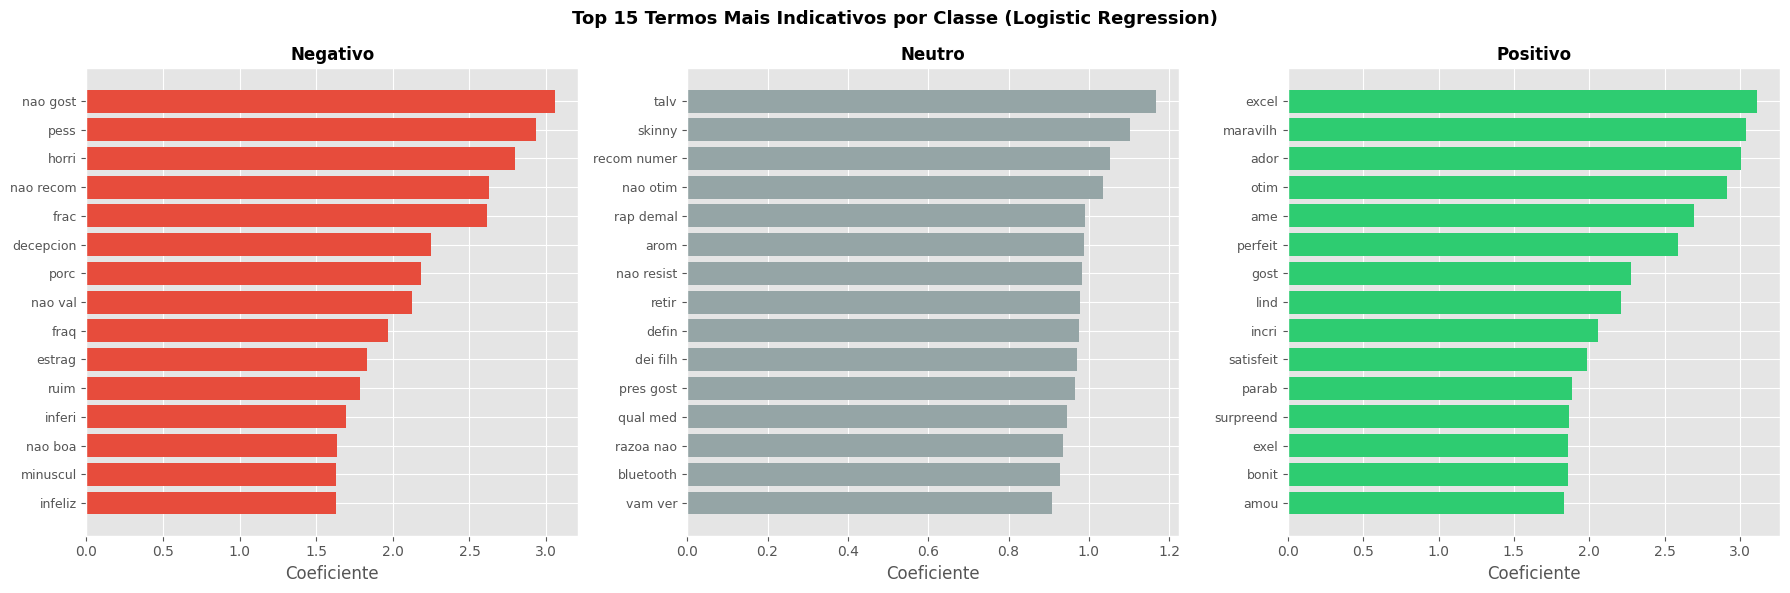


-- Top 15 termos mais indicativos por classe --

  Negativo:
    nao gost                  coef: 3.0574
    pess                      coef: 2.9326
    horri                     coef: 2.7956
    nao recom                 coef: 2.6249
    frac                      coef: 2.6158
    decepcion                 coef: 2.2458
    porc                      coef: 2.1822
    nao val                   coef: 2.1251
    fraq                      coef: 1.9667
    estrag                    coef: 1.8304
    ruim                      coef: 1.7834
    inferi                    coef: 1.6918
    nao boa                   coef: 1.6350
    minuscul                  coef: 1.6297
    infeliz                   coef: 1.6282

  Neutro:
    talv                      coef: 1.1663
    skinny                    coef: 1.1027
    recom numer               coef: 1.0529
    nao otim                  coef: 1.0357
    rap demal                 coef: 0.9900
    arom                      coef: 0.9884
    nao resist          

In [28]:
# Extraindo as palavras mais influentes por classe segundo a Logistic Regression
## A LR atribui coeficientes a cada termo do vocabulário para cada classe
## Coeficientes altos positivos = forte indicador DA classe
## Coeficientes altos negativos = forte indicador CONTRA a classe

termos = bow_vectorizer.get_feature_names_out()
coefs = gs_lr_bow.best_estimator_.coef_
classes = gs_lr_bow.best_estimator_.classes_

n_top = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cores_barras = {'Positivo': '#2ecc71', 'Negativo': '#e74c3c', 'Neutro': '#95a5a6'}

for i, classe in enumerate(classes):
    coef_classe = coefs[i]
    
    # Top termos positivos (indicadores da classe)
    top_idx = coef_classe.argsort()[-n_top:][::-1]
    top_termos = [termos[j] for j in top_idx]
    top_valores = [coef_classe[j] for j in top_idx]
    
    axes[i].barh(range(n_top), top_valores, color=cores_barras.get(classe, '#333'))
    axes[i].set_yticks(range(n_top))
    axes[i].set_yticklabels(top_termos, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_title(f'{classe}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Coeficiente')

plt.suptitle('Top 15 Termos Mais Indicativos por Classe (Logistic Regression)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/palavras_mais_relevantes_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

# Listando os termos em texto
## Facilitando a leitura dos termos mais discriminativos
print("\n-- Top 15 termos mais indicativos por classe --\n")
for i, classe in enumerate(classes):
    coef_classe = coefs[i]
    top_idx = coef_classe.argsort()[-n_top:][::-1]
    print(f"  {classe}:")
    for j in top_idx:
        print(f"    {termos[j]:<25} coef: {coef_classe[j]:.4f}")
    print()

### 11.1 Diagnóstico da Análise de Erros

#### Distribuição dos erros
O modelo acerta 86% dos reviews (11.684 acertos) e erra em 1.901 casos. Os erros se concentram na fronteira entre Neutro e as demais classes:

| Tipo de erro | Qtd | % dos erros | Interpretação |
|---|---|---|---|
| Neutro -> Positivo | 672 | 35.3% | Reviews informativos/tépidos classificados como elogio |
| Positivo -> Neutro | 375 | 19.7% | Elogios moderados ("bom", "ok") perdidos como neutro |
| Negativo -> Neutro | 354 | 18.6% | Reclamações sutis ou mistas não capturadas |
| Neutro -> Negativo | 253 | 13.3% | Reviews descritivos com termos ambíguos |
| Negativo -> Positivo | 175 | 9.2% | Erro mais grave, porém o menos frequente |
| Positivo -> Negativo | 72 | 3.8% | Erro crítico mas raro |

O erro mais grave para negócio (classificar reclamação como elogio: Negativo → Positivo) representa apenas 9.2% dos erros. O modelo é conservador onde importa.

#### Padrões encontrados nos exemplos de erros
Os reviews que o modelo mais erra compartilham uma estrutura linguística em comum: **concessão**. São reviews que começam com sentimento positivo e viram com "mas", "porém", "entretanto":
- "O produto é bom mas com menos de 1 semana já está descolando"
- "Gostei do produto, porém, faltou o medidor"
- "Bom! mas os botões se abrem com facilidade"

Essa estrutura confunde tanto o modelo de rotulação (pysentimiento) quanto o classificador. O stemming remove conectores como "mas" e "porém" (são stopwords), eliminando justamente o sinal de virada de sentimento. Isso é uma limitação conhecida de abordagens Bag of Words, que ignoram a ordem das palavras.

#### Taxa de erro por faixa de tamanho
| Faixa | Reviews | Acerto | Erro |
|---|---|---|---|
| Curto (11-30) | 2.616 | 90.3% | 9.7% |
| Médio (31-100) | 7.124 | 88.0% | 12.0% |
| Longo (101-300) | 2.650 | 80.8% | 19.2% |
| Micro (≤10) | 762 | 78.1% | 21.9% |
| Detalhado (300+) | 433 | 73.7% | 26.3% |

O padrão é claro: **reviews curtos e reviews muito longos concentram mais erros**. Reviews curtos (Micro) erram por falta de contexto, o modelo não tem informação suficiente. Reviews detalhados (300+) erram por excesso de complexidade, frequentemente misturam elogios com críticas no mesmo texto. O sweet spot do modelo é a faixa **Curto a Médio (11-100 caracteres)**, onde atinge 88-90% de acerto.

#### Interpretabilidade: coeficientes da Logistic Regression
Os termos mais discriminativos por classe confirmam a coerência do modelo:

- **Positivo:** "excel" (excelente), "maravilh" (maravilhoso), "ador" (adorei), "otim" (ótimo), "ame" (amei), "perfeit" (perfeito). Vocabulário emocional forte e inequívoco.
- **Negativo:** "nao gost" (não gostei), "pess" (péssimo), "horri" (horrível), "nao recom" (não recomendo), "frac" (fraco). Bigramas com negação dominam, confirmando que a inclusão de n-grams no vetorizador foi uma decisão acertada.
- **Neutro:** "talv" (talvez), "skinny", "recom numer" (recomendo com número/nota), "qual med" (qualidade mediana), "vam ver" (vamos ver). Vocabulário de incerteza e descrição factual.

Destaque: os dois termos mais fortes para Negativo são bigramas com negação ("nao gost", "nao recom"), o que valida a escolha de `ngram_range=(1,2)`. Sem bigramas, o modelo veria "gost" e "recom" como indicadores positivos mesmo em contexto de negação.

--- 
# **Etapa 10: Serialização do Modelo + Função de Previsão**

## 12. Serialização e Pipeline de Inferência

Empacotando o modelo final, o vetorizador e a função de pré-processamento em artefatos reutilizáveis. Isso permite classificar novos reviews sem precisar reexecutar o notebook completo.

Artefatos salvos:
- `modelo_sentimento.pkl` - Logistic Regression treinada
- `vetorizador_bow.pkl` - CountVectorizer ajustado no vocabulário de treino
- `pipeline_completo.pkl` - Dicionário com todos os componentes necessários para inferência

In [31]:
# Salvando os artefatos do modelo final
## Empacotando modelo, vetorizador e metadados em um único arquivo

import joblib

pipeline_inferencia = {
    'modelo'       : gs_lr_bow.best_estimator_,
    'vetorizador'  : bow_vectorizer,
    'stopwords'    : stop_todas,
    'stemmer'      : stemmer,
    'classes'      : ['Positivo', 'Neutro', 'Negativo'],
    'parametros'   : gs_lr_bow.best_params_,
    'metricas'     : {
        'macro_f1'  : 0.76,
        'accuracy'  : 0.86,
        'f1_pos'    : 0.93,
        'f1_neu'    : 0.59,
        'f1_neg'    : 0.76
    },
    'versao'       : '1.0',
    'data_treino'  : 'Maio/2026',
    'n_treino'     : X_train.shape[0],
    'n_teste'      : X_test.shape[0],
}

# Salvando os componentes individualmente (para uso modular)
joblib.dump(gs_lr_bow.best_estimator_, '../modelo/modelo_sentimento.pkl')
joblib.dump(bow_vectorizer, '../modelo/vetorizador_bow.pkl')

# Salvando o pipeline completo (para uso integrado)
joblib.dump(pipeline_inferencia, '../modelo/pipeline_completo.pkl')

print("Artefatos salvos em modelo/")
print(f"  modelo_sentimento.pkl")
print(f"  vetorizador_bow.pkl")
print(f"  pipeline_completo.pkl")

Artefatos salvos em modelo/
  modelo_sentimento.pkl
  vetorizador_bow.pkl
  pipeline_completo.pkl


In [32]:
# Construindo a função de previsão para novos dados
## Essa função encapsula todo o pipeline: preprocessamento → vetorização → predição

def prever_sentimento(textos, caminho_pipeline='../modelo/pipeline_completo.pkl'):
    """
    Classifica o sentimento de um ou mais reviews em português.
    
    Parâmetros:
        textos: str ou list[str] - review(s) para classificar
        caminho_pipeline: str - caminho para o arquivo pipeline_completo.pkl
    
    Retorna:
        DataFrame com colunas: review, sentimento, confianca
    """
    import joblib
    import pandas as pd
    import re
    from unidecode import unidecode
    
    # Carregando o pipeline
    pipeline = joblib.load(caminho_pipeline)
    modelo = pipeline['modelo']
    vetorizador = pipeline['vetorizador']
    stop = pipeline['stopwords']
    stemmer_local = pipeline['stemmer']
    
    # Garantindo que textos é uma lista
    if isinstance(textos, str):
        textos = [textos]
    
    # Preprocessando
    def preprocessar(texto):
        if not isinstance(texto, str):
            return ''
        texto = texto.lower()
        texto = re.sub(r'http\S+|www\S+', '', texto)
        texto = re.sub(r'[^\w\s]', ' ', texto)
        texto = re.sub(r'\d+', '', texto)
        texto = unidecode(texto)
        tokens = texto.split()
        tokens = [t for t in tokens if t not in stop and len(t) > 2]
        tokens = [stemmer_local.stem(t) for t in tokens]
        tokens = [t for t in tokens if len(t) > 2]
        return ' '.join(tokens)
    
    textos_processados = [preprocessar(t) for t in textos]
    
    # Vetorizando e prevendo
    X_vec = vetorizador.transform(textos_processados)
    predicoes = modelo.predict(X_vec)
    probabilidades = modelo.predict_proba(X_vec)
    confiancas = [max(p) for p in probabilidades]
    
    # Montando resultado
    resultado = pd.DataFrame({
        'review'     : textos,
        'sentimento' : predicoes,
        'confianca'  : [round(c, 3) for c in confiancas]
    })
    
    return resultado


# Testando a função com exemplos variados
## Simulando reviews novos que não estavam no dataset
print("-- Teste da função de previsão --\n")

reviews_novos = [
    "Produto excelente, superou todas as expectativas!",
    "Péssima qualidade, quebrou no segundo dia",
    "Chegou dentro do prazo, caixa bem embalada",
    "Não gostei, material muito fraco e acabamento ruim",
    "Bom custo benefício, recomendo para quem procura algo barato",
    "Amei! Já comprei outro de presente",
    "Horrível, pior compra que já fiz",
    "Mais ou menos, esperava mais pelo preço",
    "Mto top, recomendo dms",
    "uma bosta, n comprem"
]

resultado = prever_sentimento(reviews_novos)
for _, row in resultado.iterrows():
    icone = {'Positivo': '🟢', 'Negativo': '🔴', 'Neutro': '🟡'}[row['sentimento']]
    print(f"  {icone} [{row['sentimento']:<8} | {row['confianca']:.3f}] \"{row['review']}\"")

-- Teste da função de previsão --

  🟢 [Positivo | 1.000] "Produto excelente, superou todas as expectativas!"
  🔴 [Negativo | 0.993] "Péssima qualidade, quebrou no segundo dia"
  🟡 [Neutro   | 0.500] "Chegou dentro do prazo, caixa bem embalada"
  🔴 [Negativo | 1.000] "Não gostei, material muito fraco e acabamento ruim"
  🟢 [Positivo | 0.754] "Bom custo benefício, recomendo para quem procura algo barato"
  🟢 [Positivo | 0.958] "Amei! Já comprei outro de presente"
  🔴 [Negativo | 0.904] "Horrível, pior compra que já fiz"
  🟡 [Neutro   | 0.768] "Mais ou menos, esperava mais pelo preço"
  🟢 [Positivo | 0.942] "Mto top, recomendo dms"
  🔴 [Negativo | 0.584] "uma bosta, n comprem"


In [33]:
# Salvando checkpoint final completo
## Exportando o DataFrame com todas as colunas para análises futuras

df.to_csv('../dados/df_final_completo.csv', index=False, encoding='utf-8-sig', sep=';')

print("Dataset final salvo: dados/df_final_completo.csv")
print(f"  Shape: {df.shape}")
print(f"  Colunas: {df.columns.tolist()}")

# Verificação final dos artefatos
## Listando todos os arquivos gerados pelo projeto
import os

print(f"\n-- Artefatos do projeto --")
for pasta in ['../modelo', '../outputs', '../dados']:
    print(f"\n  {pasta}/")
    if os.path.exists(pasta):
        for f in sorted(os.listdir(pasta)):
            tamanho = os.path.getsize(os.path.join(pasta, f)) / 1024
            unidade = 'KB'
            if tamanho > 1024:
                tamanho /= 1024
                unidade = 'MB'
            print(f"    {f:<45} {tamanho:.1f} {unidade}")

Dataset final salvo: dados/df_final_completo.csv
  Shape: (67922, 13)
  Colunas: ['pesquisa', 'titulo_produto', 'link', 'review', 'plataforma', 'len_review', 'categoria', 'n_palavras', 'faixa_tamanho', 'sentimento', 'confianca', 'review_processado', 'len_processado']

-- Artefatos do projeto --

  ../modelo/
    modelo_sentimento.pkl                         235.4 KB
    pipeline_completo.pkl                         542.3 KB
    vetorizador_bow.pkl                           295.4 KB

  ../outputs/
    comparacao_antes_depois_tuning.png            90.2 KB
    distribuicao_sentimentos.png                  76.9 KB
    matriz_confusao_melhor_modelo.png             50.7 KB
    palavras_mais_relevantes_por_classe.png       83.9 KB
    sentimento_por_categoria.png                  60.7 KB
    sentimento_por_faixa_tamanho.png              46.8 KB
    sentimento_por_plataforma.png                 46.1 KB
    tamanho_review_sentimento.png                 58.4 KB
    top_bottom_pesquisas.png      